In [135]:
# Установка библиотек
# pip install pmdarima
# pip install prophet

# Игнор предупреждений
import warnings
warnings.filterwarnings("ignore")

# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels
import statsmodels.api as sm
import statsmodels.tsa.api as smt

# Автоподбор параметров ARIMA
from pmdarima.arima import auto_arima

# Модели ARIMA / SARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ACF / PACF
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тест Дики — Фуллера на стационарность
from statsmodels.tsa.stattools import adfuller

# Декомпозиция временного ряда
from statsmodels.tsa.seasonal import seasonal_decompose

# Prophet
from prophet import Prophet

# xgboost
import xgboost as xgb

# Метрика качества
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Plotly как backend для pandas
# pd.options.plotting.backend = "plotly"

pd.options.plotting.backend = "matplotlib"

# Стиль графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Импорт типа для создания упорядоченных категориальных переменных в pandas
from pandas.api.types import CategoricalDtype

# Отображение графиков внутри ноутбука
%matplotlib inline

In [136]:
# Устанавливаем Plotly как backend для pandas plotting
# Теперь все вызовы .plot() будут возвращать интерактивные графики Plotly вместо matplotlib

pd.options.plotting.backend = "plotly"

In [137]:
df = pd.read_excel('Alfa_TS.xlsx')
df.head()

,Месяц,Основной отпуск,Больничный лист
0,2022-01-01,2644,3118
1,2022-02-01,6812,3023
2,2022-03-01,7933,1475
3,2022-04-01,8649,1368
4,2022-05-01,9548,1459


In [138]:
df.rename(columns={'Месяц': 'Time', 'Основной отпуск': 'Vacation', 'Больничный лист': 'Sick Leave'}, inplace=True)

In [139]:
df.head()

,Time,Vacation,Sick Leave
0,2022-01-01,2644,3118
1,2022-02-01,6812,3023
2,2022-03-01,7933,1475
3,2022-04-01,8649,1368
4,2022-05-01,9548,1459


In [140]:
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

In [141]:
df = df.asfreq('MS')  # MS - начало месяца


Декомпозиция для Vacation (отпуска)


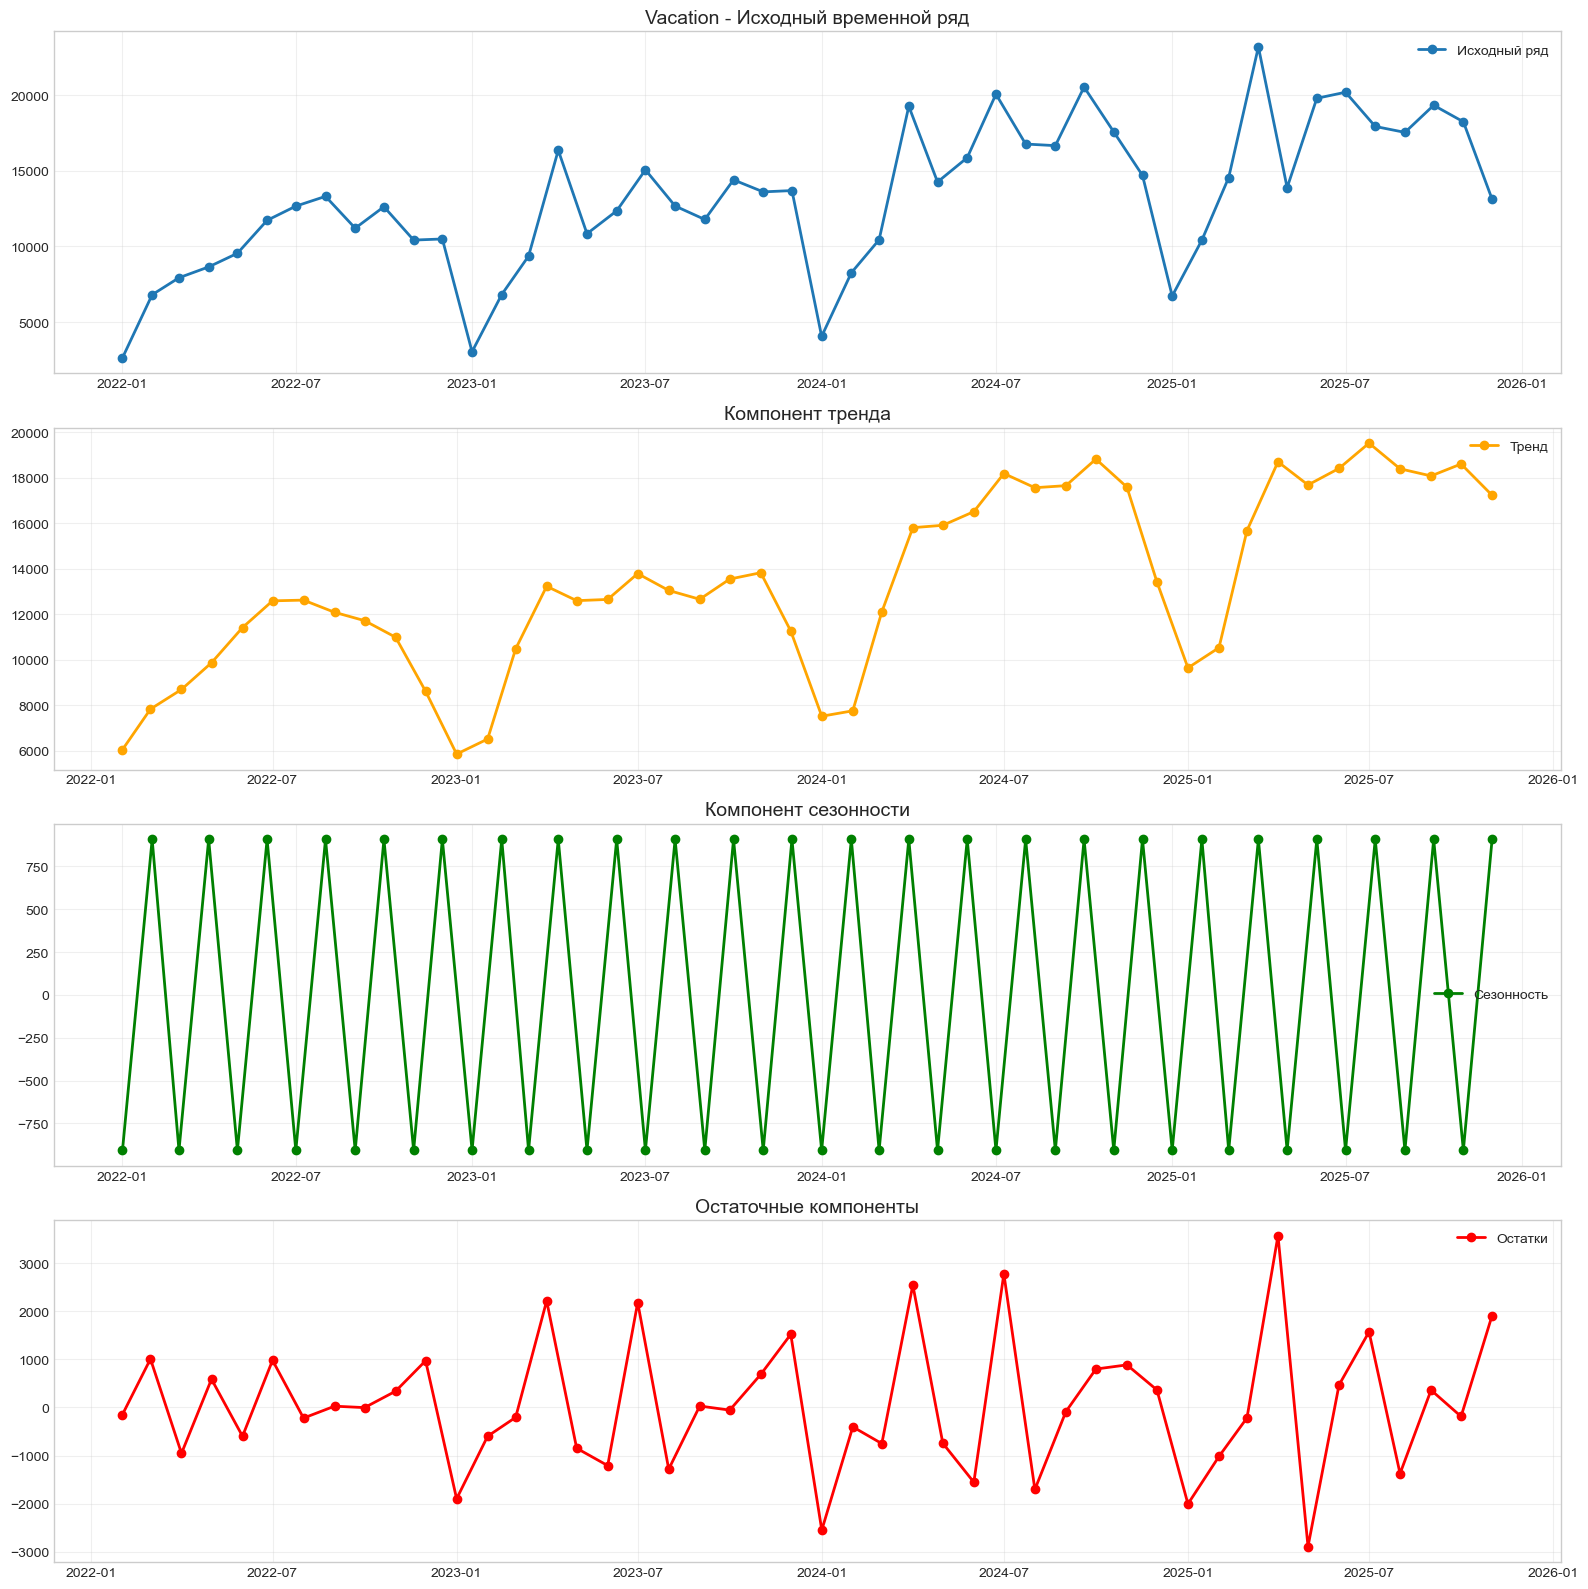


Декомпозиция для Sick Leave (больничные)


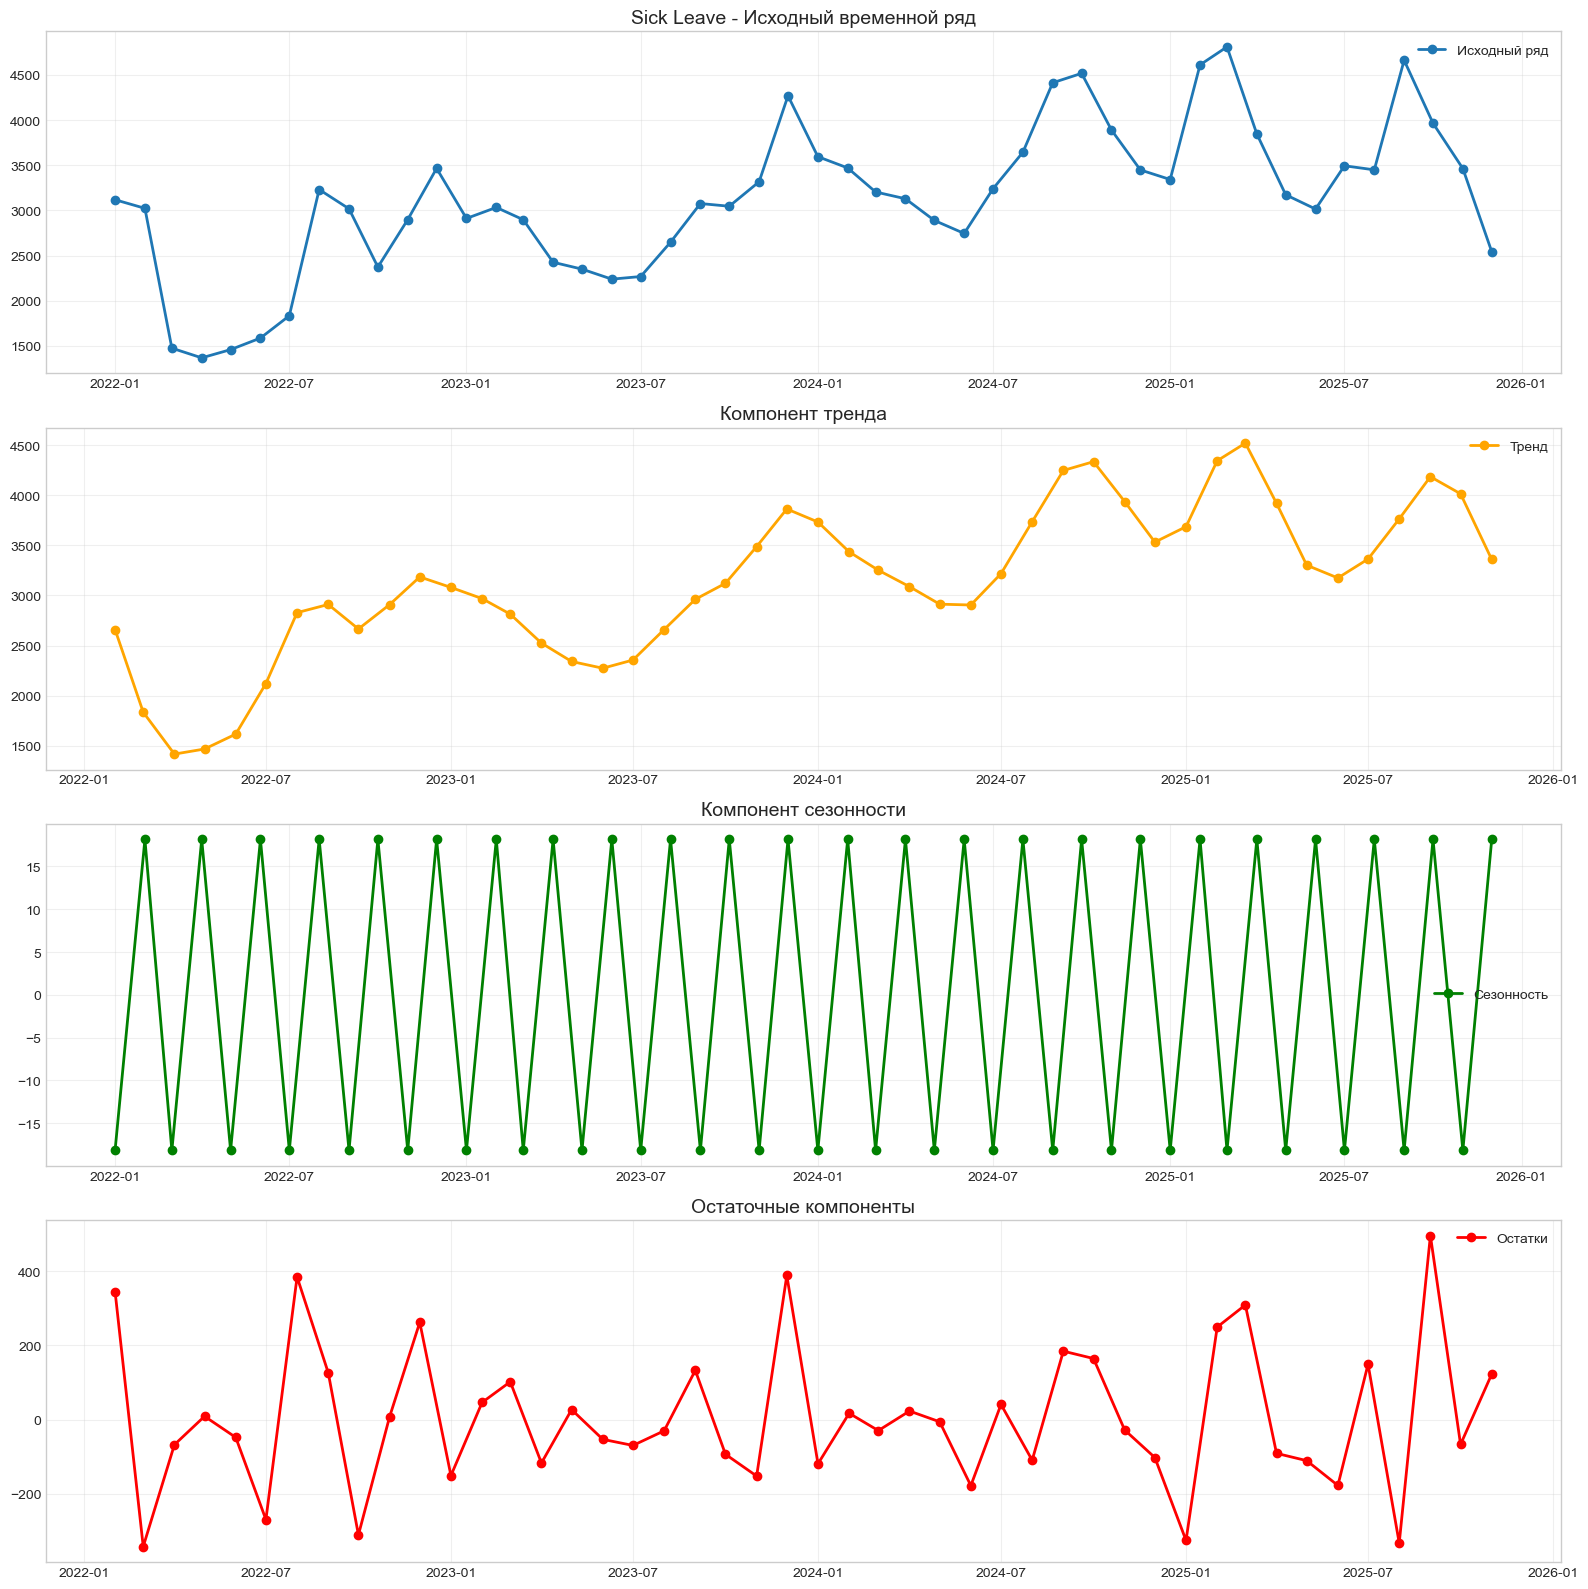

In [142]:
def plot_decomposition(series, title):
    # Выполняем декомпозицию (период=12 для годовой сезонности)
    # Для 5 точек период должен быть меньше, используем период=2
    period = min(2, len(series)//2) if len(series) >= 4 else 2
    
    try:
        decomposition = seasonal_decompose(series, model='additive', period=period)
        
        # Извлечение компонентов
        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid
        
        # Визуализация
        plt.figure(figsize=(16, 16))
        
        # График исходного ряда
        plt.subplot(411)
        plt.plot(series.index, series, label='Исходный ряд', linewidth=2, marker='o')
        plt.legend(loc='best')
        plt.title(f'{title} - Исходный временной ряд', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # График тренда
        plt.subplot(412)
        plt.plot(trend, label='Тренд', linewidth=2, marker='o', color='orange')
        plt.legend(loc='best')
        plt.title('Компонент тренда', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # График сезонности
        plt.subplot(413)
        plt.plot(seasonal, label='Сезонность', linewidth=2, marker='o', color='green')
        plt.legend(loc='best')
        plt.title('Компонент сезонности', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # График остатков
        plt.subplot(414)
        plt.plot(residual, label='Остатки', linewidth=2, marker='o', color='red')
        plt.legend(loc='best')
        plt.title('Остаточные компоненты', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return decomposition
        
    except Exception as e:
        print(f"Ошибка при декомпозиции {title}: {e}")
        return None

# Декомпозиция для Vacation
print("\n" + "="*50)
print("Декомпозиция для Vacation (отпуска)")
print("="*50)
decomp_vacation = plot_decomposition(df['Vacation'], 'Vacation')

# Декомпозиция для Sick Leave
print("\n" + "="*50)
print("Декомпозиция для Sick Leave (больничные)")
print("="*50)
decomp_sick = plot_decomposition(df['Sick Leave'], 'Sick Leave')

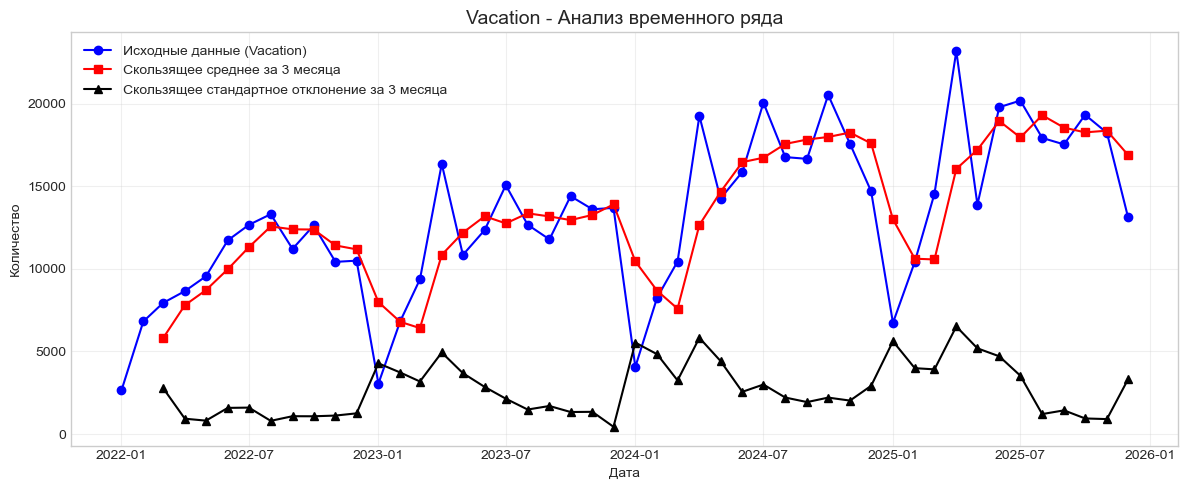

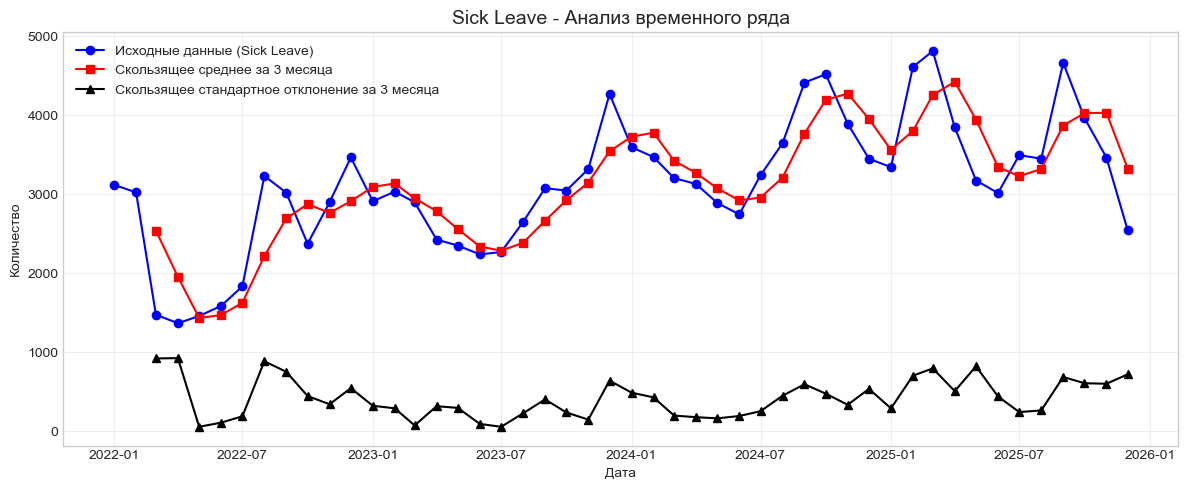

In [143]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Vacation'], color="blue", label="Исходные данные (Vacation)", marker='o')
rolling_mean = df['Vacation'].rolling(3).mean()  # Для 5 точек используем окно 3
plt.plot(df.index, rolling_mean, color="red", label="Скользящее среднее за 3 месяца", marker='s')
rolling_std = df['Vacation'].rolling(3).std()
plt.plot(df.index, rolling_std, color="black", label="Скользящее стандартное отклонение за 3 месяца", marker='^')
plt.title('Vacation - Анализ временного ряда', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График для Sick Leave
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Sick Leave'], color="blue", label="Исходные данные (Sick Leave)", marker='o')
rolling_mean = df['Sick Leave'].rolling(3).mean()
plt.plot(df.index, rolling_mean, color="red", label="Скользящее среднее за 3 месяца", marker='s')
rolling_std = df['Sick Leave'].rolling(3).std()
plt.plot(df.index, rolling_std, color="black", label="Скользящее стандартное отклонение за 3 месяца", marker='^')
plt.title('Sick Leave - Анализ временного ряда', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [145]:
# Разделение на обучающую (80%) и тестовую (20%) выборки
train_size = int(len(df) * 0.8)  # 80% на обучение
test_size = len(df) - train_size   # 20% на тест

# Разделяем для Vacation
train_vacation = df['Vacation'].iloc[:train_size]
test_vacation = df['Vacation'].iloc[train_size:]

# Разделяем для Sick Leave
train_sick = df['Sick Leave'].iloc[:train_size]
test_sick = df['Sick Leave'].iloc[train_size:]

print(f"Всего наблюдений: {len(df)}")
print(f"Обучающая выборка: {train_size} наблюдений ({train_size/len(df)*100:.0f}%)")
print(f"Тестовая выборка: {test_size} наблюдений ({test_size/len(df)*100:.0f}%)")
print(f"\nПериод обучения: {train_vacation.index[0].strftime('%Y-%m-%d')} - {train_vacation.index[-1].strftime('%Y-%m-%d')}")
print(f"Период тестирования: {test_vacation.index[0].strftime('%Y-%m-%d')} - {test_vacation.index[-1].strftime('%Y-%m-%d')}")

Всего наблюдений: 48
Обучающая выборка: 38 наблюдений (79%)
Тестовая выборка: 10 наблюдений (21%)

Период обучения: 2022-01-01 - 2025-02-01
Период тестирования: 2025-03-01 - 2025-12-01


Проверка стационарности для Vacation


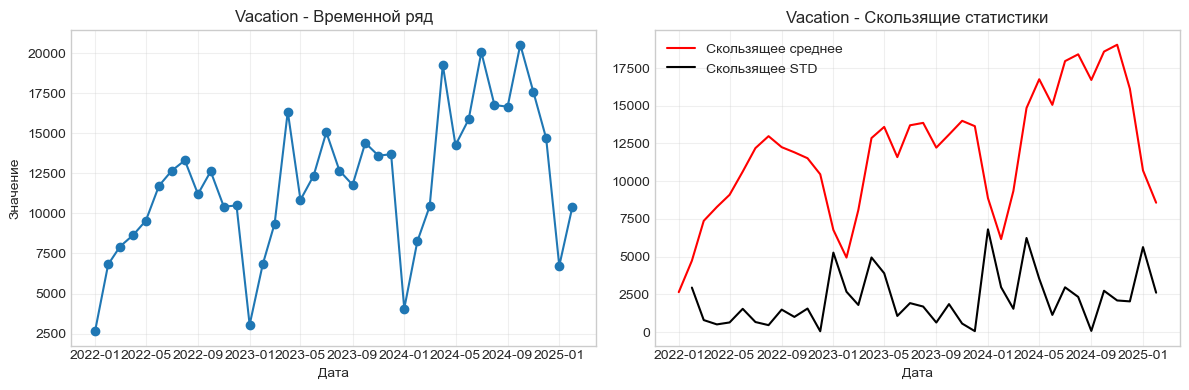

Проверка стационарности для Sick Leave


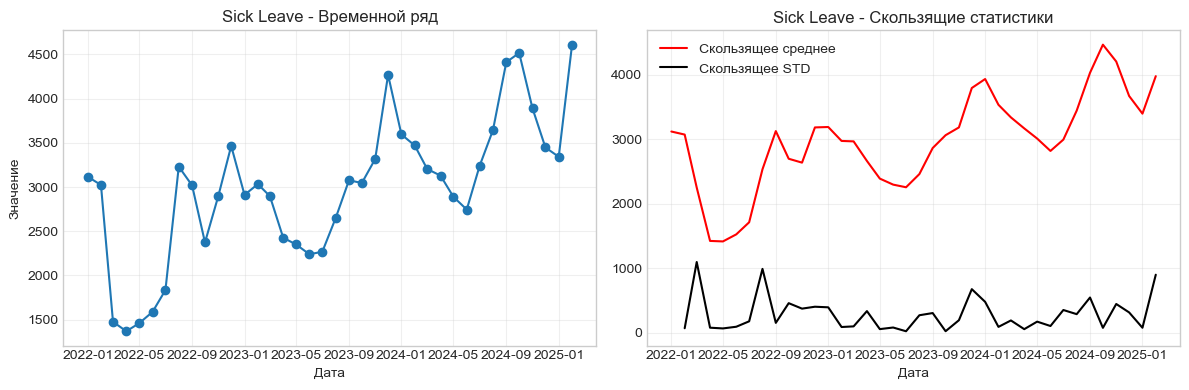

In [146]:
# Простая визуальная проверка стационарности (без теста Дики-Фуллера)
def check_stationarity_simple(series, title):
    print(f"Проверка стационарности для {title}")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # График ряда
    ax1.plot(series.index, series.values, marker='o')
    ax1.set_title(f'{title} - Временной ряд')
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.grid(True, alpha=0.3)
    
    # Скользящее среднее и стандартное отклонение
    rolling_mean = series.rolling(window=min(2, len(series)//2), min_periods=1).mean()
    rolling_std = series.rolling(window=min(2, len(series)//2), min_periods=1).std()
    
    ax2.plot(series.index, rolling_mean, label='Скользящее среднее', color='red')
    ax2.plot(series.index, rolling_std, label='Скользящее STD', color='black')
    ax2.set_title(f'{title} - Скользящие статистики')
    ax2.set_xlabel('Дата')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Использование упрощенной функции
is_stationary_vac = check_stationarity_simple(train_vacation, 'Vacation')
is_stationary_sick = check_stationarity_simple(train_sick, 'Sick Leave')

Оба ряда не стационарны, применяем дифференцирование

In [147]:
train_vacation_diff = train_vacation.diff().dropna() if not is_stationary_vac else train_vacation
train_sick_diff = train_sick.diff().dropna() if not is_stationary_sick else train_sick

Анализ ACF и PACF для Vacation (после дифференцирования):


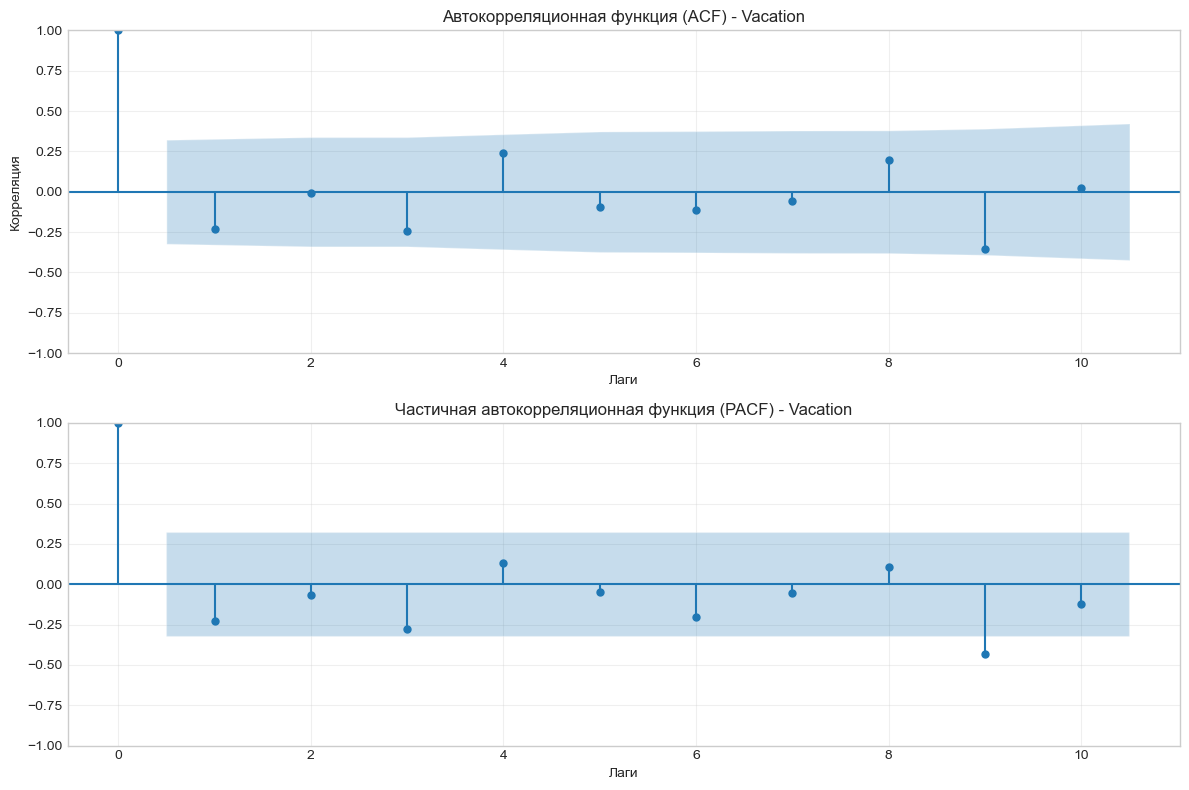


Анализ ACF и PACF для Sick Leave (после дифференцирования):


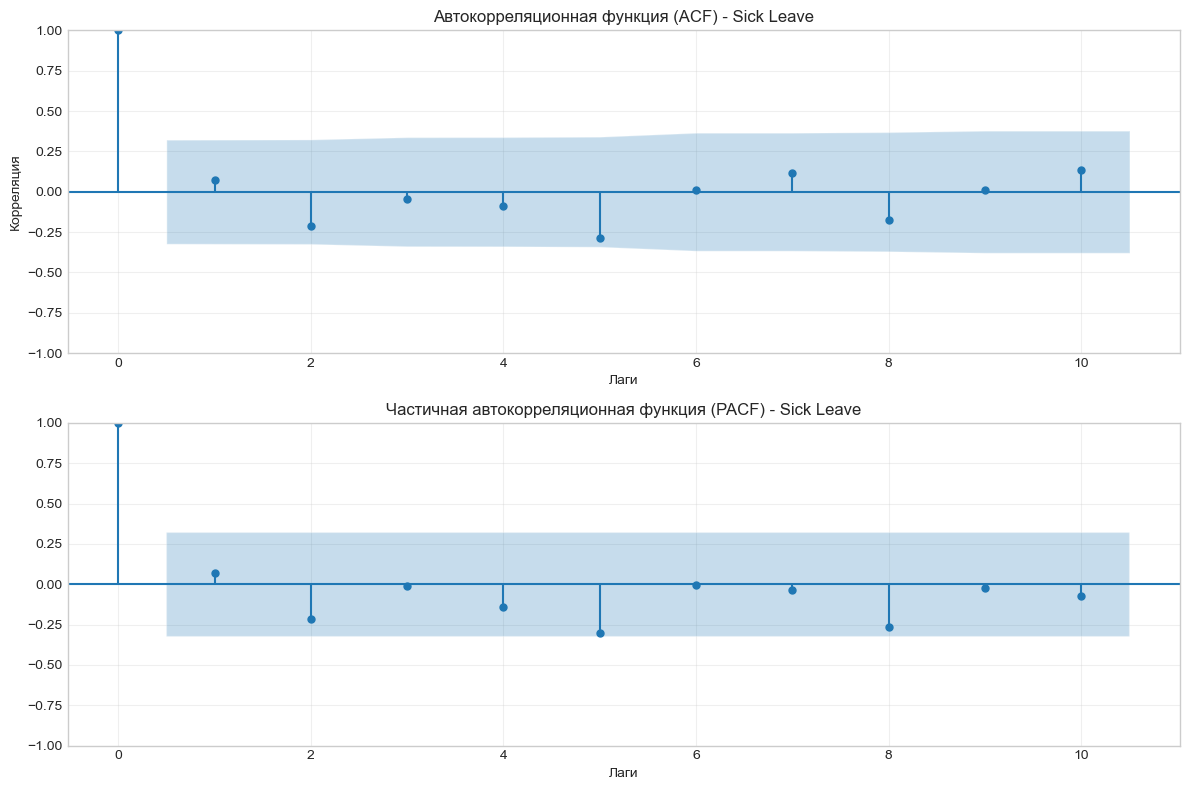

In [148]:
# Построение графиков ACF и PACF для определения параметров p и q
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Функция для построения ACF и PACF
def plot_acf_pacf(series, title):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # ACF график
    plot_acf(series, ax=ax1, lags=min(10, len(series)//2), alpha=0.05)
    ax1.set_title(f'Автокорреляционная функция (ACF) - {title}', fontsize=12)
    ax1.set_xlabel('Лаги')
    ax1.set_ylabel('Корреляция')
    ax1.grid(True, alpha=0.3)
    
    # PACF график
    plot_pacf(series, ax=ax2, lags=min(10, len(series)//2), alpha=0.05, method='ywm')
    ax2.set_title(f'Частичная автокорреляционная функция (PACF) - {title}', fontsize=12)
    ax2.set_xlabel('Лаги')
    ax2.set_ylabel='Частичная корреляция'
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построение графиков для продифференцированных рядов
print("Анализ ACF и PACF для Vacation (после дифференцирования):")
plot_acf_pacf(train_vacation_diff, 'Vacation')

print("\nАнализ ACF и PACF для Sick Leave (после дифференцирования):")
plot_acf_pacf(train_sick_diff, 'Sick Leave')

In [149]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Функция для поиска лучших параметров ARIMA
def find_best_arima_params(train_data, d=1, p_range=[0,1,2], q_range=[0,1,2]):
    """
    Поиск оптимальных параметров ARIMA по минимальному AIC
    """
    best_aic = float('inf')
    best_order = None
    results = []
    
    print(f"Поиск оптимальных параметров ARIMA (d={d})...")
    print("="*60)
    
    for p in p_range:
        for q in q_range:
            try:
                model = ARIMA(train_data, order=(p, d, q))
                fitted = model.fit()
                aic = fitted.aic
                results.append((p, q, aic))
                print(f"Параметры (p={p}, d={d}, q={q}): AIC = {aic:.2f}")
                
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
            except Exception as e:
                print(f"Параметры (p={p}, d={d}, q={q}): ошибка - {str(e)[:50]}")
                continue
    
    print("="*60)
    print(f"Лучшие параметры: order={best_order} с AIC = {best_aic:.2f}")
    
    return best_order, results

# Поиск лучших параметров для Vacation
print("ПОИСК ПАРАМЕТРОВ ДЛЯ VACATION")
best_order_vac, results_vac = find_best_arima_params(train_vacation, d=1)

print("\n" + "="*60)
print("ПОИСК ПАРАМЕТРОВ ДЛЯ SICK LEAVE")
best_order_sick, results_sick = find_best_arima_params(train_sick, d=1)

ПОИСК ПАРАМЕТРОВ ДЛЯ VACATION
Поиск оптимальных параметров ARIMA (d=1)...
Параметры (p=0, d=1, q=0): AIC = 719.64
Параметры (p=0, d=1, q=1): AIC = 719.68
Параметры (p=0, d=1, q=2): AIC = 721.95
Параметры (p=1, d=1, q=0): AIC = 719.93
Параметры (p=1, d=1, q=1): AIC = 720.03
Параметры (p=1, d=1, q=2): AIC = 720.51
Параметры (p=2, d=1, q=0): AIC = 721.85
Параметры (p=2, d=1, q=1): AIC = 721.83
Параметры (p=2, d=1, q=2): AIC = 720.43
Лучшие параметры: order=(0, 1, 0) с AIC = 719.64

ПОИСК ПАРАМЕТРОВ ДЛЯ SICK LEAVE
Поиск оптимальных параметров ARIMA (d=1)...
Параметры (p=0, d=1, q=0): AIC = 574.12
Параметры (p=0, d=1, q=1): AIC = 575.62
Параметры (p=0, d=1, q=2): AIC = 571.97
Параметры (p=1, d=1, q=0): AIC = 575.95
Параметры (p=1, d=1, q=1): AIC = 576.26
Параметры (p=1, d=1, q=2): AIC = 573.10
Параметры (p=2, d=1, q=0): AIC = 573.32
Параметры (p=2, d=1, q=1): AIC = 575.31
Параметры (p=2, d=1, q=2): AIC = 575.00
Лучшие параметры: order=(0, 1, 2) с AIC = 571.97


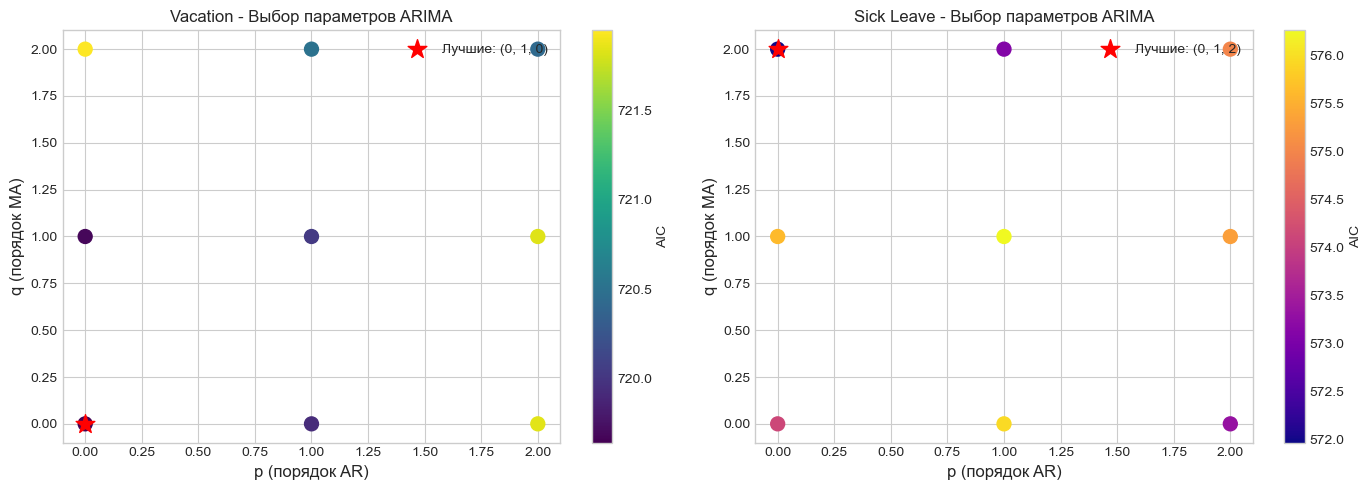


✅ Рекомендуемые параметры:
Vacation: ARIMA(0, 1, 0)
Sick Leave: ARIMA(0, 1, 2)


In [150]:
# Визуализация результатов поиска параметров
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Для Vacation
if results_vac:
    p_vals = [r[0] for r in results_vac]
    q_vals = [r[1] for r in results_vac]
    aic_vals = [r[2] for r in results_vac]
    
    scatter = ax1.scatter(p_vals, q_vals, c=aic_vals, cmap='viridis', s=100)
    ax1.set_xlabel('p (порядок AR)', fontsize=12)
    ax1.set_ylabel('q (порядок MA)', fontsize=12)
    ax1.set_title('Vacation - Выбор параметров ARIMA', fontsize=12)
    plt.colorbar(scatter, ax=ax1, label='AIC')
    
    # Отмечаем лучшие параметры
    if best_order_vac:
        ax1.scatter(best_order_vac[0], best_order_vac[2], color='red', s=200, marker='*', 
                   label=f'Лучшие: {best_order_vac}')
        ax1.legend()

# Для Sick Leave
if results_sick:
    p_vals = [r[0] for r in results_sick]
    q_vals = [r[1] for r in results_sick]
    aic_vals = [r[2] for r in results_sick]
    
    scatter = ax2.scatter(p_vals, q_vals, c=aic_vals, cmap='plasma', s=100)
    ax2.set_xlabel('p (порядок AR)', fontsize=12)
    ax2.set_ylabel('q (порядок MA)', fontsize=12)
    ax2.set_title('Sick Leave - Выбор параметров ARIMA', fontsize=12)
    plt.colorbar(scatter, ax=ax2, label='AIC')
    
    if best_order_sick:
        ax2.scatter(best_order_sick[0], best_order_sick[2], color='red', s=200, marker='*',
                   label=f'Лучшие: {best_order_sick}')
        ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Рекомендуемые параметры:")
print(f"Vacation: ARIMA{best_order_vac}")
print(f"Sick Leave: ARIMA{best_order_sick}")

In [151]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Функция для построения и оценки модели
def build_and_evaluate_arima(train_data, test_data, column_name, order):
    """
    Построение модели ARIMA и оценка качества
    """
    print(f"\n{'='*60}")
    print(f"Модель ARIMA{order} для {column_name}")
    print('='*60)
    
    # Обучение модели
    model = ARIMA(train_data, order=order)
    fitted_model = model.fit()
    
    print(f"\n📊 Информация о модели:")
    print(f"AIC: {fitted_model.aic:.2f}")
    print(f"BIC: {fitted_model.bic:.2f}")
    print(f"HQIC: {fitted_model.hqic:.2f}")
    
    # Прогнозирование
    forecast = fitted_model.forecast(steps=len(test_data))
    
    # Метрики качества
    mse = mean_squared_error(test_data, forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_data, forecast)
    mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
    
    print(f"\n📈 Метрики качества на тестовой выборке:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    
    # Дополнительная диагностика
    residuals = fitted_model.resid
    print(f"\n🔍 Диагностика остатков:")
    print(f"Среднее остатков: {residuals.mean():.4f}")
    print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
    
    return fitted_model, forecast

# Построение моделей с найденными оптимальными параметрами
# Если поиск не удался, используем параметры по умолчанию
if best_order_vac is None:
    best_order_vac = (1, 1, 1)
    print("Используем параметры по умолчанию для Vacation: (1,1,1)")

if best_order_sick is None:
    best_order_sick = (1, 1, 1)
    print("Используем параметры по умолчанию для Sick Leave: (1,1,1)")

# Построение моделей
model_vacation, forecast_vacation = build_and_evaluate_arima(
    train_vacation, test_vacation, 'Vacation', best_order_vac
)

model_sick, forecast_sick = build_and_evaluate_arima(
    train_sick, test_sick, 'Sick Leave', best_order_sick
)


Модель ARIMA(0, 1, 0) для Vacation

📊 Информация о модели:
AIC: 719.64
BIC: 721.25
HQIC: 720.21

📈 Метрики качества на тестовой выборке:
MSE: 62962675.30
RMSE: 7934.90
MAE: 7353.10
MAPE: 39.61%

🔍 Диагностика остатков:
Среднее остатков: 274.1842
Стандартное отклонение остатков: 3953.4984

Модель ARIMA(0, 1, 2) для Sick Leave

📊 Информация о модели:
AIC: 571.97
BIC: 576.80
HQIC: 573.67

📈 Метрики качества на тестовой выборке:
MSE: 592848.56
RMSE: 769.97
MAE: 647.88
MAPE: 20.33%

🔍 Диагностика остатков:
Среднее остатков: 168.8512
Стандартное отклонение остатков: 703.0820


Модель ARIMA(0,1,2) для "Sick Leave" работает отлично - ошибка около 20% по метрике MAPE, а модель ARIMA(0,1,0) для "Vacation" показывает очень низкую точность.

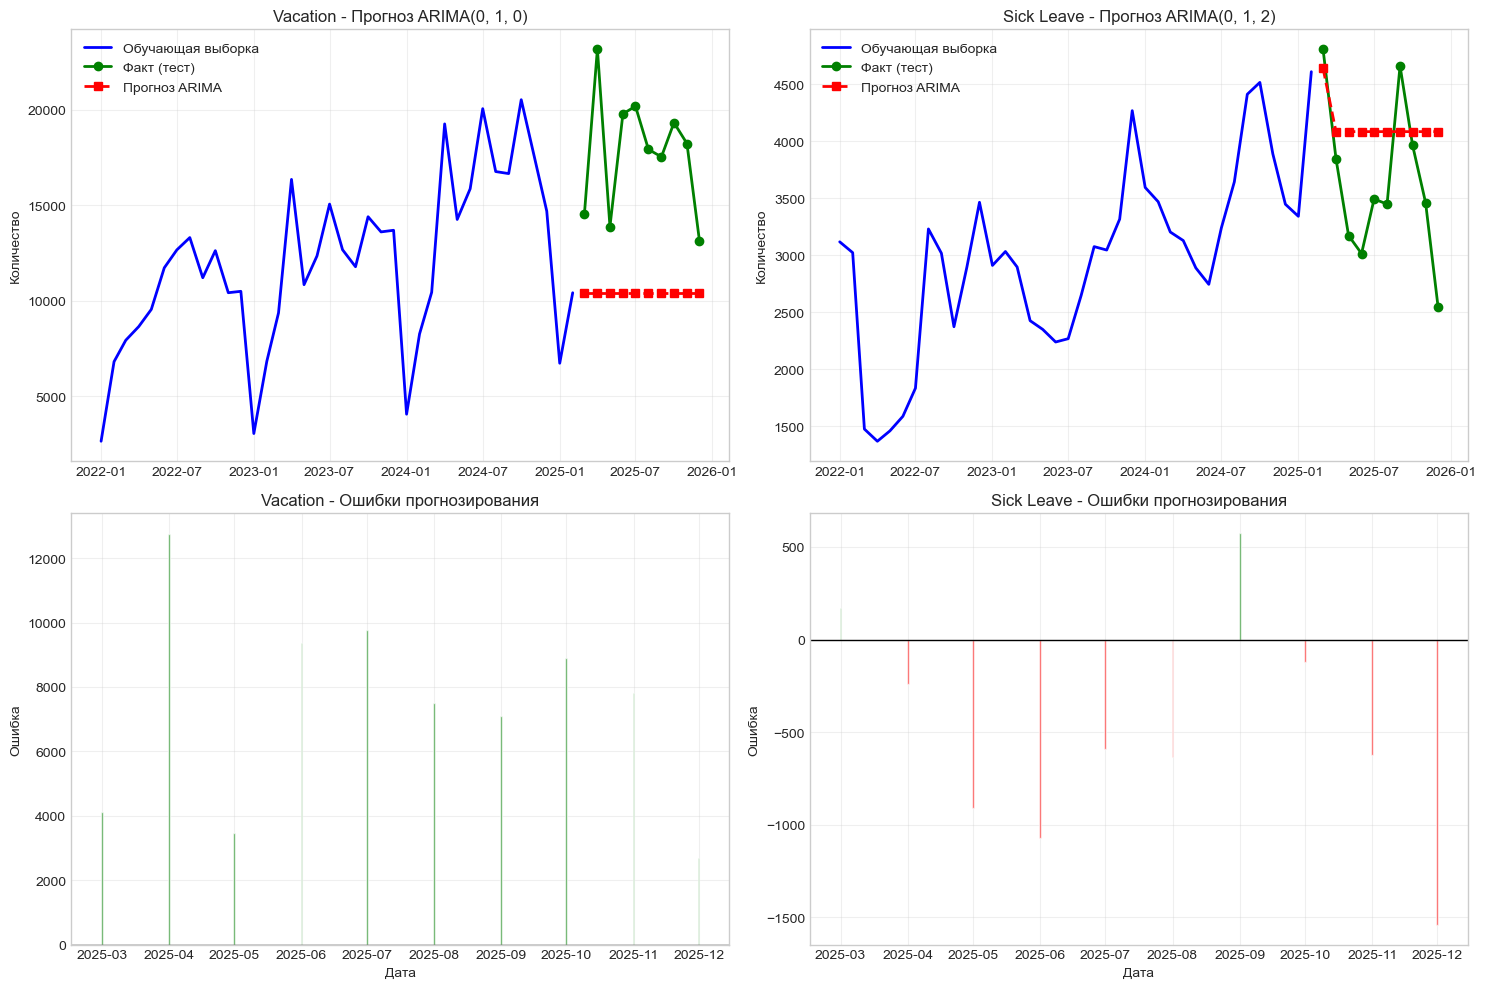

In [152]:
# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: Vacation - обучающая и тестовая выборки
axes[0, 0].plot(train_vacation.index, train_vacation, label='Обучающая выборка', color='blue', linewidth=2)
axes[0, 0].plot(test_vacation.index, test_vacation, label='Факт (тест)', color='green', linewidth=2, marker='o')
axes[0, 0].plot(test_vacation.index, forecast_vacation, label='Прогноз ARIMA', color='red', linewidth=2, marker='s', linestyle='--')
axes[0, 0].set_title(f'Vacation - Прогноз ARIMA{best_order_vac}', fontsize=12)
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Sick Leave - обучающая и тестовая выборки
axes[0, 1].plot(train_sick.index, train_sick, label='Обучающая выборка', color='blue', linewidth=2)
axes[0, 1].plot(test_sick.index, test_sick, label='Факт (тест)', color='green', linewidth=2, marker='o')
axes[0, 1].plot(test_sick.index, forecast_sick, label='Прогноз ARIMA', color='red', linewidth=2, marker='s', linestyle='--')
axes[0, 1].set_title(f'Sick Leave - Прогноз ARIMA{best_order_sick}', fontsize=12)
axes[0, 1].set_ylabel('Количество')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Сравнение ошибок для Vacation
errors_vac = test_vacation.values - forecast_vacation
axes[1, 0].bar(test_vacation.index, errors_vac, color=['red' if x < 0 else 'green' for x in errors_vac], alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_title('Vacation - Ошибки прогнозирования', fontsize=12)
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Ошибка')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Сравнение ошибок для Sick Leave
errors_sick = test_sick.values - forecast_sick
axes[1, 1].bar(test_sick.index, errors_sick, color=['red' if x < 0 else 'green' for x in errors_sick], alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_title('Sick Leave - Ошибки прогнозирования', fontsize=12)
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Ошибка')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

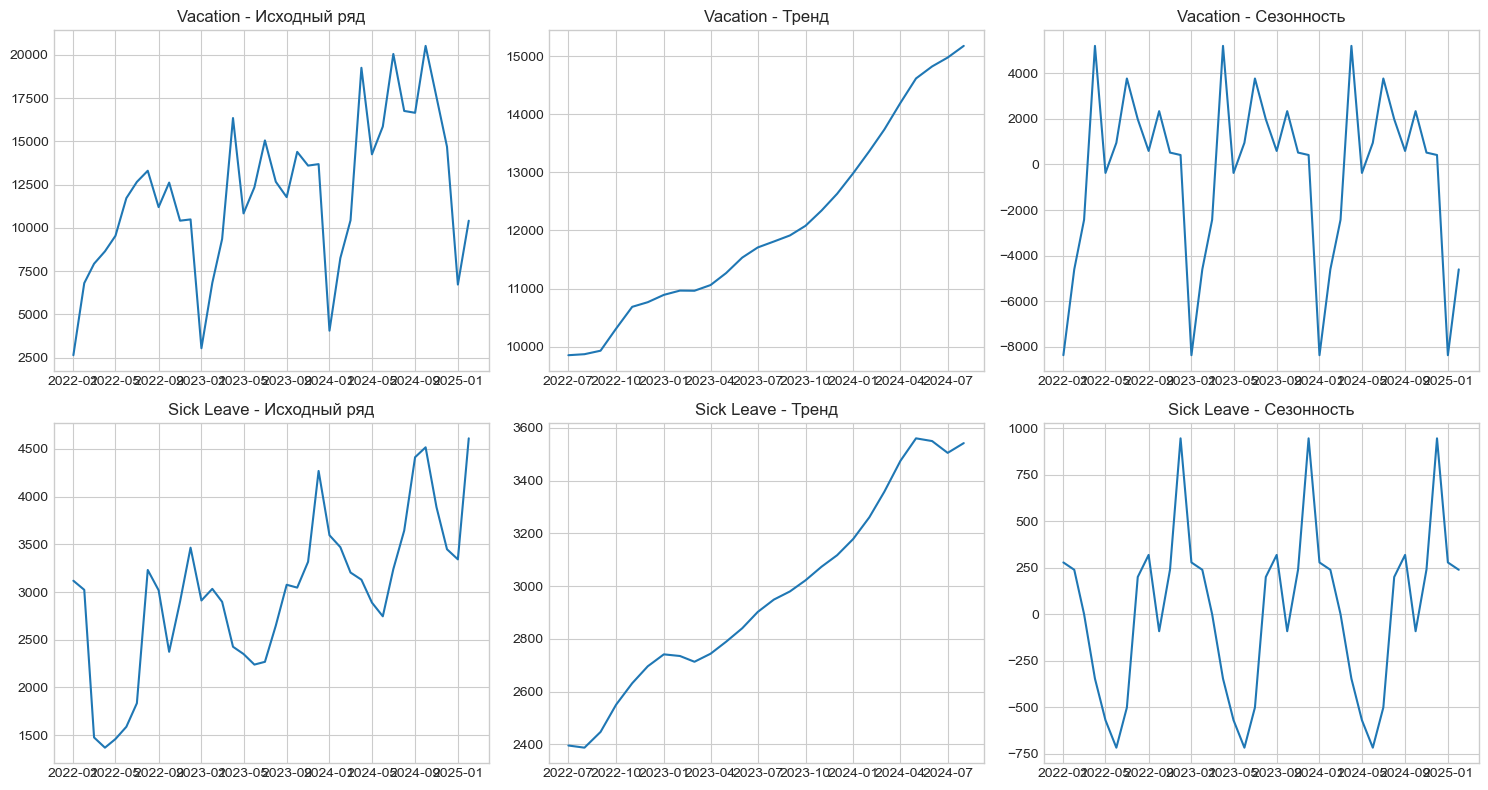

✓ Сезонная декомпозиция выполнена
Рекомендуемый сезонный период: 12 (месяцев)


In [154]:
# Определение сезонного периода
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция для определения сезонности
try:
    # Для месячных данных сезонный период обычно 12
    decomposition_vac = seasonal_decompose(train_vacation, model='additive', period=min(12, len(train_vacation)//2))
    decomposition_sick = seasonal_decompose(train_sick, model='additive', period=min(12, len(train_sick)//2))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Vacation
    axes[0, 0].plot(decomposition_vac.observed)
    axes[0, 0].set_title('Vacation - Исходный ряд')
    axes[0, 1].plot(decomposition_vac.trend)
    axes[0, 1].set_title('Vacation - Тренд')
    axes[0, 2].plot(decomposition_vac.seasonal)
    axes[0, 2].set_title('Vacation - Сезонность')
    
    # Sick Leave
    axes[1, 0].plot(decomposition_sick.observed)
    axes[1, 0].set_title('Sick Leave - Исходный ряд')
    axes[1, 1].plot(decomposition_sick.trend)
    axes[1, 1].set_title('Sick Leave - Тренд')
    axes[1, 2].plot(decomposition_sick.seasonal)
    axes[1, 2].set_title('Sick Leave - Сезонность')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Сезонная декомпозиция выполнена")
    print("Рекомендуемый сезонный период: 12 (месяцев)")
    
except Exception as e:
    print(f"Недостаточно данных для декомпозиции: {e}")
    print("Используем сезонный период = 12 (для месячных данных)")

In [155]:
from itertools import product

def find_best_sarima_params(train_data, seasonal_period=12, 
                           p_range=[0,1], d_range=[0,1], q_range=[0,1],
                           P_range=[0,1], D_range=[0,1], Q_range=[0,1]):
    """
    Поиск оптимальных параметров SARIMA по минимальному AIC
    """
    best_aic = float('inf')
    best_params = None
    results = []
    
    # Перебор всех комбинаций
    total_combinations = len(p_range) * len(d_range) * len(q_range) * \
                        len(P_range) * len(D_range) * len(Q_range)
    
    print(f"Поиск оптимальных параметров SARIMA...")
    print(f"Всего комбинаций: {total_combinations}")
    print(f"Сезонный период: {seasonal_period}")
    print("="*70)
    
    counter = 0
    for p, d, q in product(p_range, d_range, q_range):
        for P, D, Q in product(P_range, D_range, Q_range):
            try:
                counter += 1
                model = SARIMAX(train_data, 
                               order=(p, d, q),
                               seasonal_order=(P, D, Q, seasonal_period),
                               enforce_stationarity=False,
                               enforce_invertibility=False)
                fitted = model.fit(disp=False)
                aic = fitted.aic
                
                results.append({
                    'order': (p, d, q),
                    'seasonal_order': (P, D, Q, seasonal_period),
                    'aic': aic
                })
                
                print(f"({counter}/{total_combinations}) SARIMA{(p,d,q)}x{(P,D,Q,seasonal_period)}: AIC = {aic:.2f}")
                
                if aic < best_aic:
                    best_aic = aic
                    best_params = ((p, d, q), (P, D, Q, seasonal_period))
                    
            except Exception as e:
                continue
    
    print("="*70)
    print(f"Лучшие параметры: SARIMA{best_params[0]}x{best_params[1]}")
    print(f"Лучший AIC: {best_aic:.2f}")
    
    return best_params, results

# Поиск параметров для Vacation (если данных достаточно)
if len(train_vacation) >= 24:
    print("ПОИСК ПАРАМЕТРОВ ДЛЯ VACATION")
    best_params_vac, results_vac = find_best_sarima_params(
        train_vacation, 
        seasonal_period=12,
        p_range=[0,1,2], d_range=[0,1], q_range=[0,1],
        P_range=[0,1], D_range=[0,1], Q_range=[0,1]
    )
else:
    print("⚠️ Данных недостаточно для автоматического поиска параметров")
    print("Используем рекомендуемые параметры:")
    best_params_vac = ((1,1,1), (1,0,1,12))
    print(f"Vacation: SARIMA{best_params_vac[0]}x{best_params_vac[1]}")

ПОИСК ПАРАМЕТРОВ ДЛЯ VACATION
Поиск оптимальных параметров SARIMA...
Всего комбинаций: 96
Сезонный период: 12
(1/96) SARIMA(0, 0, 0)x(0, 0, 0, 12): AIC = 807.20
(2/96) SARIMA(0, 0, 0)x(0, 0, 1, 12): AIC = 1060.01
(3/96) SARIMA(0, 0, 0)x(0, 1, 0, 12): AIC = 477.06
(4/96) SARIMA(0, 0, 0)x(0, 1, 1, 12): AIC = 253.13
(5/96) SARIMA(0, 0, 0)x(1, 0, 0, 12): AIC = 468.92
(6/96) SARIMA(0, 0, 0)x(1, 0, 1, 12): AIC = 938.27
(7/96) SARIMA(0, 0, 0)x(1, 1, 0, 12): AIC = 265.88
(8/96) SARIMA(0, 0, 0)x(1, 1, 1, 12): AIC = 234.72
(9/96) SARIMA(0, 0, 1)x(0, 0, 0, 12): AIC = 767.27
(10/96) SARIMA(0, 0, 1)x(0, 0, 1, 12): AIC = 2649.17
(11/96) SARIMA(0, 0, 1)x(0, 1, 0, 12): AIC = 449.38
(12/96) SARIMA(0, 0, 1)x(0, 1, 1, 12): AIC = 225.71
(13/96) SARIMA(0, 0, 1)x(1, 0, 0, 12): AIC = 470.21
(14/96) SARIMA(0, 0, 1)x(1, 0, 1, 12): AIC = 816.19
(15/96) SARIMA(0, 0, 1)x(1, 1, 0, 12): AIC = 260.34
(16/96) SARIMA(0, 0, 1)x(1, 1, 1, 12): AIC = 226.68
(17/96) SARIMA(0, 1, 0)x(0, 0, 0, 12): AIC = 700.13
(18/96) SARIM

In [156]:
if len(train_sick) >= 24:
    print("\nПОИСК ПАРАМЕТРОВ ДЛЯ SICK LEAVE")
    best_params_sick, results_sick = find_best_sarima_params(
        train_sick, 
        seasonal_period=12,
        p_range=[0,1,2], d_range=[0,1], q_range=[0,1],
        P_range=[0,1], D_range=[0,1], Q_range=[0,1]
    )
else:
    print("\n⚠️ Данных недостаточно для автоматического поиска параметров")
    print("Используем рекомендуемые параметры:")
    best_params_sick = ((1,1,1), (1,0,1,12))
    print(f"Sick Leave: SARIMA{best_params_sick[0]}x{best_params_sick[1]}")


ПОИСК ПАРАМЕТРОВ ДЛЯ SICK LEAVE
Поиск оптимальных параметров SARIMA...
Всего комбинаций: 96
Сезонный период: 12
(1/96) SARIMA(0, 0, 0)x(0, 0, 0, 12): AIC = 701.67
(2/96) SARIMA(0, 0, 0)x(0, 0, 1, 12): AIC = 1289.18
(3/96) SARIMA(0, 0, 0)x(0, 1, 0, 12): AIC = 407.52
(4/96) SARIMA(0, 0, 0)x(0, 1, 1, 12): AIC = 215.86
(5/96) SARIMA(0, 0, 0)x(1, 0, 0, 12): AIC = 414.33
(6/96) SARIMA(0, 0, 0)x(1, 0, 1, 12): AIC = 399.75
(7/96) SARIMA(0, 0, 0)x(1, 1, 0, 12): AIC = 230.98
(8/96) SARIMA(0, 0, 0)x(1, 1, 1, 12): AIC = 212.65
(9/96) SARIMA(0, 0, 1)x(0, 0, 0, 12): AIC = 644.69
(10/96) SARIMA(0, 0, 1)x(0, 0, 1, 12): AIC = 2015.30
(11/96) SARIMA(0, 0, 1)x(0, 1, 0, 12): AIC = 376.04
(12/96) SARIMA(0, 0, 1)x(0, 1, 1, 12): AIC = 190.72
(13/96) SARIMA(0, 0, 1)x(1, 0, 0, 12): AIC = 406.68
(14/96) SARIMA(0, 0, 1)x(1, 0, 1, 12): AIC = 374.52
(15/96) SARIMA(0, 0, 1)x(1, 1, 0, 12): AIC = 220.46
(16/96) SARIMA(0, 0, 1)x(1, 1, 1, 12): AIC = 192.71
(17/96) SARIMA(0, 1, 0)x(0, 0, 0, 12): AIC = 559.61
(18/96) SA

In [157]:
def build_sarima_model(train_data, test_data, column_name, order, seasonal_order):
    """
    Построение SARIMA модели и оценка качества
    """
    print(f"\n{'='*70}")
    print(f"Модель SARIMA{order}x{seasonal_order} для {column_name}")
    print('='*70)
    
    # Обучение модели
    model = SARIMAX(train_data, 
                    order=order, 
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    fitted_model = model.fit(disp=False)
    
    print(f"\n📊 Информация о модели:")
    print(f"AIC: {fitted_model.aic:.2f}")
    print(f"BIC: {fitted_model.bic:.2f}")
    print(f"HQIC: {fitted_model.hqic:.2f}")
    
    # Прогнозирование
    forecast = fitted_model.forecast(steps=len(test_data))
    forecast_index = test_data.index
    
    # Метрики качества
    mse = mean_squared_error(test_data, forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_data, forecast)
    mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
    
    print(f"\n📈 Метрики качества на тестовой выборке:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    
    # Диагностика остатков
    residuals = fitted_model.resid
    print(f"\n🔍 Диагностика остатков:")
    print(f"Среднее остатков: {residuals.mean():.4f}")
    print(f"Стандартное отклонение: {residuals.std():.4f}")
    
    # Тест на нормальность остатков (если данных достаточно)
    if len(residuals) > 5:
        from scipy import stats
        _, p_value = stats.normaltest(residuals.dropna())
        print(f"p-value теста на нормальность: {p_value:.4f}")
        if p_value > 0.05:
            print("✓ Остатки распределены нормально")
        else:
            print("⚠️ Остатки не распределены нормально")
    
    return fitted_model, forecast

# Построение моделей
print("="*70)
print("ПОСТРОЕНИЕ SARIMA МОДЕЛЕЙ")
print("="*70)

model_vacation, forecast_vacation = build_sarima_model(
    train_vacation, test_vacation, 'Vacation', 
    best_params_vac[0], best_params_vac[1]
)

model_sick, forecast_sick = build_sarima_model(
    train_sick, test_sick, 'Sick Leave',
    best_params_sick[0], best_params_sick[1]
)

ПОСТРОЕНИЕ SARIMA МОДЕЛЕЙ

Модель SARIMA(0, 1, 1)x(1, 1, 1, 12) для Vacation

📊 Информация о модели:
AIC: 192.67
BIC: 194.26
HQIC: 191.66

📈 Метрики качества на тестовой выборке:
MSE: 4291499.50
RMSE: 2071.59
MAE: 1731.03
MAPE: 10.63%

🔍 Диагностика остатков:
Среднее остатков: 9.0474
Стандартное отклонение: 2530.9718
p-value теста на нормальность: 0.0080
⚠️ Остатки не распределены нормально

Модель SARIMA(2, 1, 1)x(0, 1, 1, 12) для Sick Leave

📊 Информация о модели:
AIC: 172.59
BIC: 174.58
HQIC: 171.34

📈 Метрики качества на тестовой выборке:
MSE: 716677.44
RMSE: 846.57
MAE: 633.83
MAPE: 19.73%

🔍 Диагностика остатков:
Среднее остатков: 11.7540
Стандартное отклонение: 937.6249
p-value теста на нормальность: 0.0077
⚠️ Остатки не распределены нормально


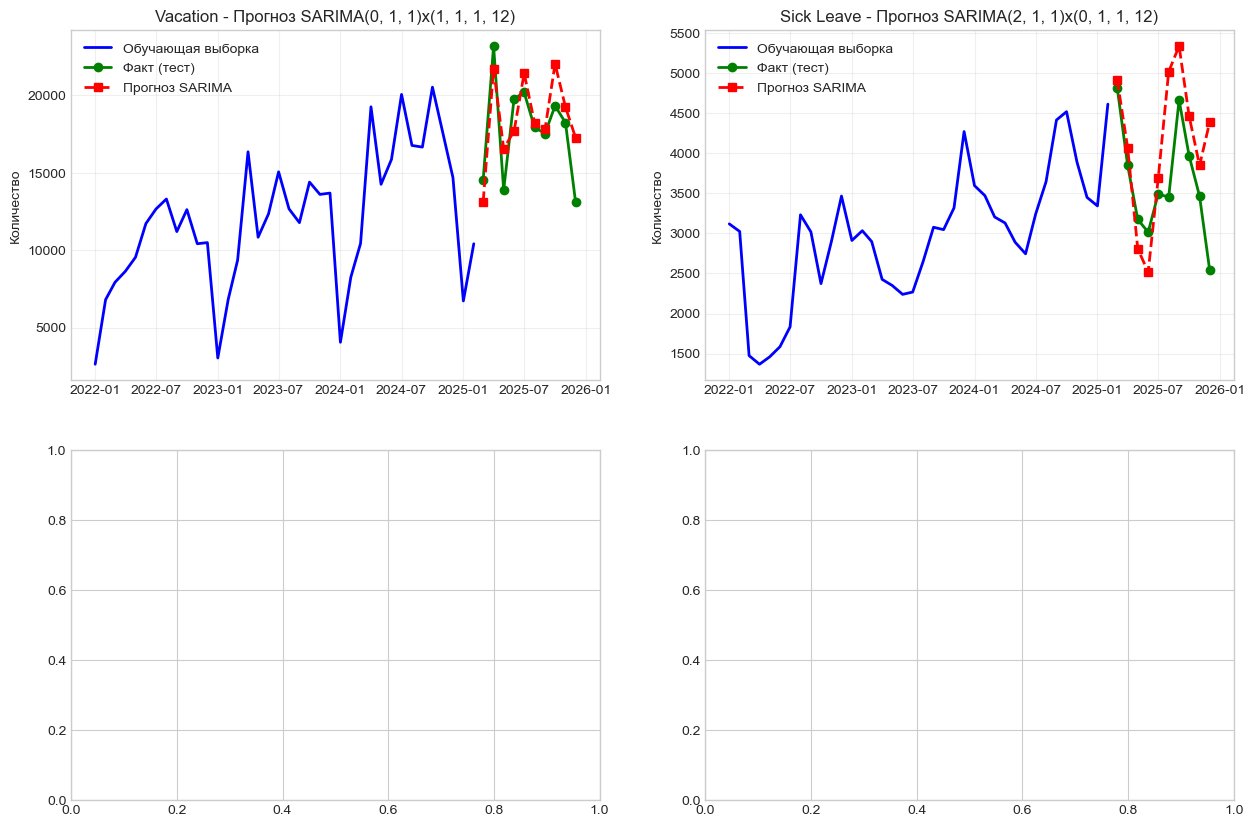

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Vacation - прогноз
axes[0, 0].plot(train_vacation.index, train_vacation, label='Обучающая выборка', color='blue', linewidth=2)
axes[0, 0].plot(test_vacation.index, test_vacation, label='Факт (тест)', color='green', linewidth=2, marker='o')
axes[0, 0].plot(test_vacation.index, forecast_vacation, label='Прогноз SARIMA', color='red', linewidth=2, marker='s', linestyle='--')
axes[0, 0].set_title(f'Vacation - Прогноз SARIMA{best_params_vac[0]}x{best_params_vac[1]}', fontsize=12)
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sick Leave - прогноз
axes[0, 1].plot(train_sick.index, train_sick, label='Обучающая выборка', color='blue', linewidth=2)
axes[0, 1].plot(test_sick.index, test_sick, label='Факт (тест)', color='green', linewidth=2, marker='o')
axes[0, 1].plot(test_sick.index, forecast_sick, label='Прогноз SARIMA', color='red', linewidth=2, marker='s', linestyle='--')
axes[0, 1].set_title(f'Sick Leave - Прогноз SARIMA{best_params_sick[0]}x{best_params_sick[1]}', fontsize=12)
axes[0, 1].set_ylabel('Количество')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

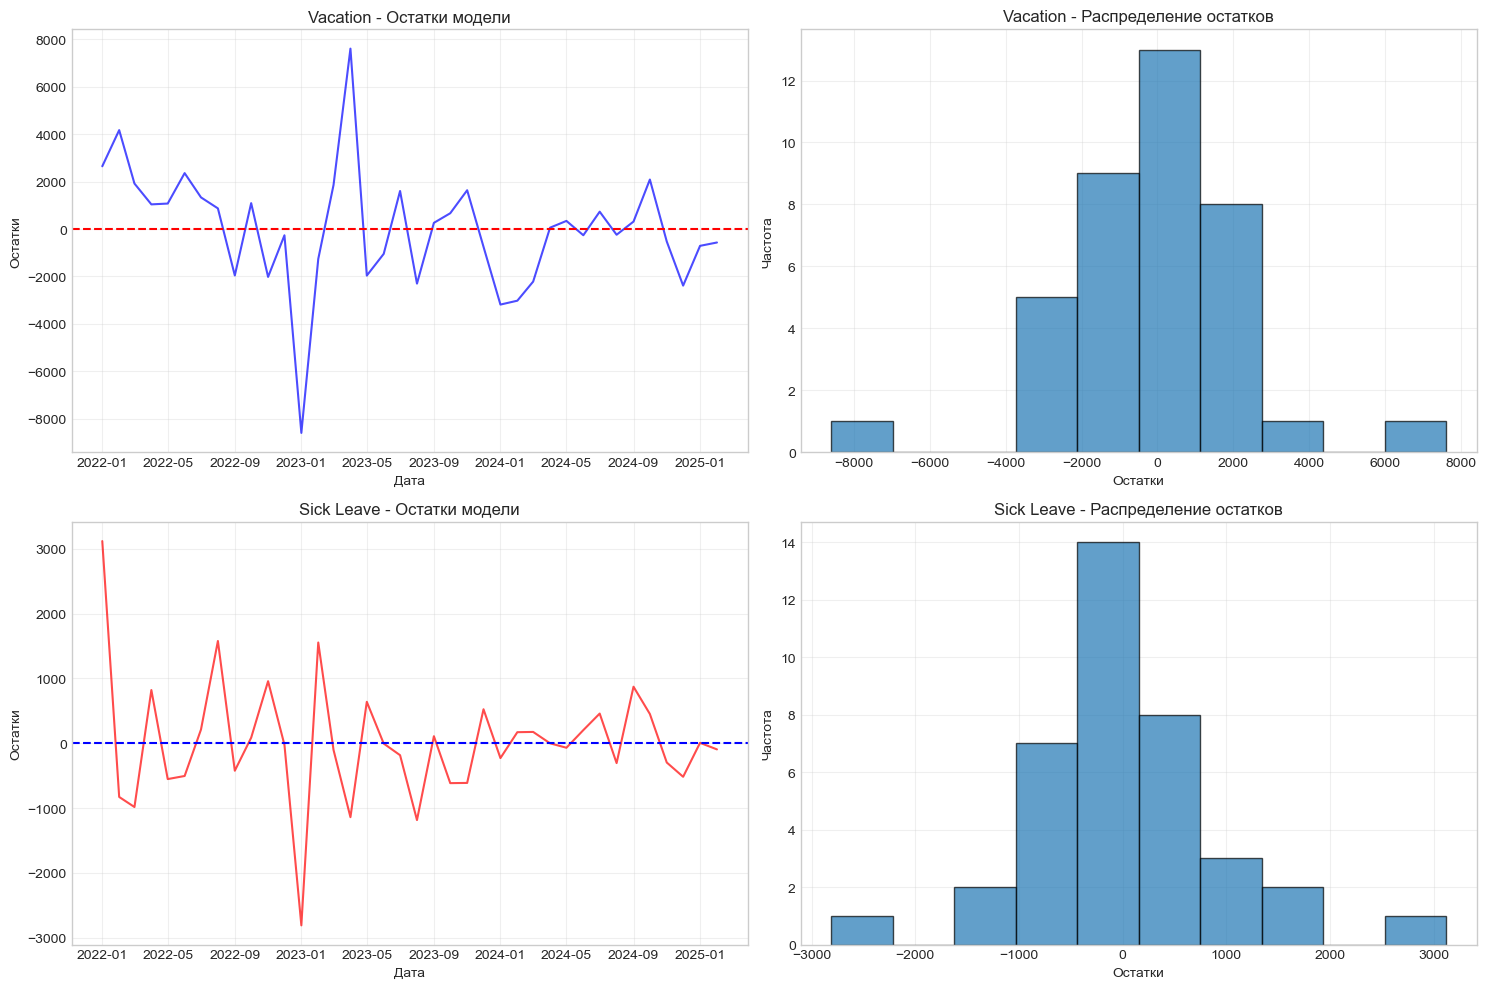


Статистика остатков (Vacation):
Среднее: 9.0474
Стандартное отклонение: 2530.9718
Медиана: 157.6995

Статистика остатков (Sick Leave):
Среднее: 11.7540
Стандартное отклонение: 937.6249
Медиана: -14.5932


In [159]:
# Анализ остатков для проверки адекватности модели
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Остатки модели Vacation
residuals_vac = model_vacation.resid
axes[0, 0].plot(residuals_vac.index, residuals_vac.values, color='blue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Vacation - Остатки модели', fontsize=12)
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма остатков Vacation
axes[0, 1].hist(residuals_vac.dropna(), bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Vacation - Распределение остатков', fontsize=12)
axes[0, 1].set_xlabel('Остатки')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

# Остатки модели Sick Leave
residuals_sick = model_sick.resid
axes[1, 0].plot(residuals_sick.index, residuals_sick.values, color='red', alpha=0.7)
axes[1, 0].axhline(y=0, color='blue', linestyle='--')
axes[1, 0].set_title('Sick Leave - Остатки модели', fontsize=12)
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Остатки')
axes[1, 0].grid(True, alpha=0.3)

# Гистограмма остатков Sick Leave
axes[1, 1].hist(residuals_sick.dropna(), bins=10, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Sick Leave - Распределение остатков', fontsize=12)
axes[1, 1].set_xlabel('Остатки')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика остатков
print("\nСтатистика остатков (Vacation):")
print(f"Среднее: {residuals_vac.mean():.4f}")
print(f"Стандартное отклонение: {residuals_vac.std():.4f}")
print(f"Медиана: {residuals_vac.median():.4f}")

print("\nСтатистика остатков (Sick Leave):")
print(f"Среднее: {residuals_sick.mean():.4f}")
print(f"Стандартное отклонение: {residuals_sick.std():.4f}")
print(f"Медиана: {residuals_sick.median():.4f}")

ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ (SARIMA)

Дата            Vacation             Vacation (95% ДИ)         Sick Leave           Sick Leave (95% ДИ)      
---------------------------------------------------------------------------------------------------------
2026-01-01      13134                [10875 - 15394]            4911                 [4141 - 5682]
2026-02-01      21722                [19444 - 24000]            4065                 [3090 - 5039]
2026-03-01      16552                [14262 - 18843]            2808                 [1817 - 3799]
2026-04-01      17694                [15391 - 19996]            2517                 [1349 - 3684]
2026-05-01      21427                [19113 - 23741]            3691                 [2506 - 4875]
2026-06-01      18220                [15894 - 20545]            5014                 [3743 - 6286]


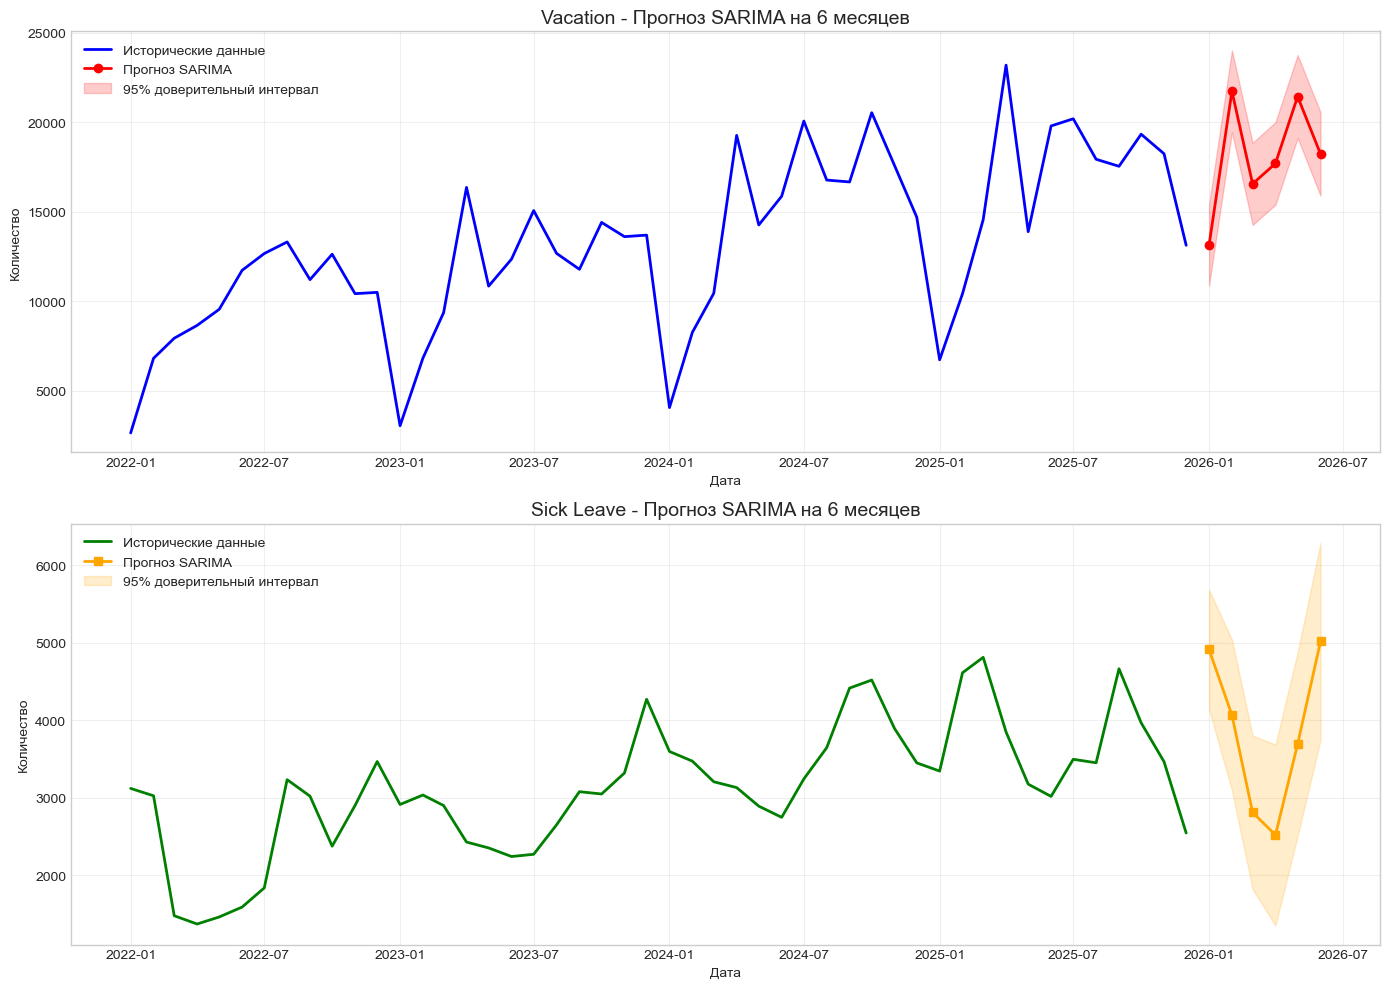

In [160]:
# Прогноз на следующие 6 месяцев
future_steps = 6
forecast_future_vac = model_vacation.forecast(steps=future_steps)
forecast_future_sick = model_sick.forecast(steps=future_steps)

# Доверительные интервалы
forecast_result_vac = model_vacation.get_forecast(steps=future_steps)
forecast_result_sick = model_sick.get_forecast(steps=future_steps)

# Доверительные интервалы (95%)
conf_int_vac = forecast_result_vac.conf_int()
conf_int_sick = forecast_result_sick.conf_int()

# Даты для прогноза
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')

# Вывод прогноза
print("="*70)
print("ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ (SARIMA)")
print("="*70)

print(f"\n{'Дата':<15} {'Vacation':<20} {'Vacation (95% ДИ)':<25} {'Sick Leave':<20} {'Sick Leave (95% ДИ)':<25}")
print("-"*105)

for i, date in enumerate(future_dates):
    vac_lower = conf_int_vac.iloc[i, 0]
    vac_upper = conf_int_vac.iloc[i, 1]
    sick_lower = conf_int_sick.iloc[i, 0]
    sick_upper = conf_int_sick.iloc[i, 1]
    
    print(f"{date.strftime('%Y-%m-%d'):<15} "
          f"{forecast_future_vac.iloc[i]:<20.0f} "
          f"[{vac_lower:.0f} - {vac_upper:.0f}] {'':<10} "
          f"{forecast_future_sick.iloc[i]:<20.0f} "
          f"[{sick_lower:.0f} - {sick_upper:.0f}]")

# Визуализация прогноза с доверительными интервалами
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Vacation с доверительным интервалом
ax1.plot(df.index, df['Vacation'], label='Исторические данные', color='blue', linewidth=2)
ax1.plot(future_dates, forecast_future_vac, label='Прогноз SARIMA', color='red', linewidth=2, marker='o')
ax1.fill_between(future_dates, conf_int_vac.iloc[:, 0], conf_int_vac.iloc[:, 1], 
                  color='red', alpha=0.2, label='95% доверительный интервал')
ax1.set_title('Vacation - Прогноз SARIMA на 6 месяцев', fontsize=14)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sick Leave с доверительным интервалом
ax2.plot(df.index, df['Sick Leave'], label='Исторические данные', color='green', linewidth=2)
ax2.plot(future_dates, forecast_future_sick, label='Прогноз SARIMA', color='orange', linewidth=2, marker='s')
ax2.fill_between(future_dates, conf_int_sick.iloc[:, 0], conf_int_sick.iloc[:, 1], 
                  color='orange', alpha=0.2, label='95% доверительный интервал')
ax2.set_title('Sick Leave - Прогноз SARIMA на 6 месяцев', fontsize=14)
ax2.set_xlabel('Дата')
ax2.set_ylabel('Количество')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [161]:
df.rename(columns={'Месяц': 'Time', 'Основной отпуск': 'Vacation', 'Больничный лист': 'Sick Leave'}, inplace=True)

In [162]:
# Установка Prophet (если не установлен)
# !pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [163]:
# ==================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ PROPHET И XGBOOST
# ==================================================

# Prophet требует определенный формат данных: колонки 'ds' (дата) и 'y' (значение)
def prepare_prophet_data(series, name):
    """
    Подготавливает данные для модели Prophet
    """
    df_prophet = pd.DataFrame({
        'ds': series.index,
        'y': series.values
    })
    # Разделение на train/test для Prophet
    train_end_date = train_vacation.index[-1]  # Берем последнюю дату обучения
    train_prophet = df_prophet[df_prophet['ds'] <= train_end_date].copy()
    test_prophet = df_prophet[df_prophet['ds'] > train_end_date].copy()
    return train_prophet, test_prophet

# Для XGBoost необходимо создать признаки на основе даты
def create_features(df, target_col):
    """
    Создает признаки из даты для XGBoost модели
    """
    data = df.copy()
    # Базовые временные признаки
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['quarter'] = data.index.quarter
    data['dayofweek'] = data.index.dayofweek
    data['dayofyear'] = data.index.dayofyear
    data['weekofyear'] = data.index.isocalendar().week.astype(int)
    
    # Циклические признаки для месяца (для учета сезонности)
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    
    # Лаговые признаки (используем предыдущие значения)
    for lag in [1, 2, 3, 6, 12]:
        data[f'lag_{lag}'] = data[target_col].shift(lag)
    
    # Скользящие средние
    data['rolling_mean_3'] = data[target_col].rolling(window=3).mean()
    data['rolling_mean_6'] = data[target_col].rolling(window=6).mean()
    data['rolling_std_3'] = data[target_col].rolling(window=3).std()
    
    return data.dropna()

print("✓ Функции для подготовки данных созданы")

✓ Функции для подготовки данных созданы


23:31:36 - cmdstanpy - INFO - Chain [1] start processing



МОДЕЛЬ PROPHET - Прогнозирование Vacation (Отпуска)


23:31:36 - cmdstanpy - INFO - Chain [1] done processing


✓ Модель Prophet для Vacation обучена


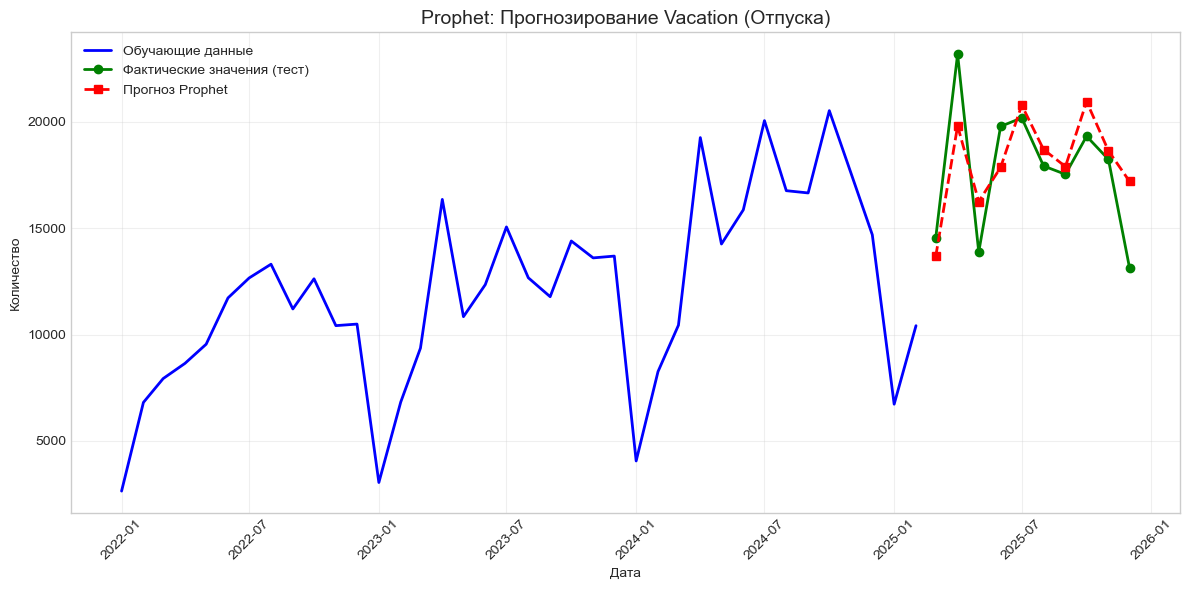

✓ Прогноз Prophet для Vacation построен


In [164]:
# ==================================================
# МОДЕЛЬ PROPHET - VACATION (ОТПУСКА)
# ==================================================

print("\n" + "="*60)
print("МОДЕЛЬ PROPHET - Прогнозирование Vacation (Отпуска)")
print("="*60)

# Подготовка данных
train_prophet_vac, test_prophet_vac = prepare_prophet_data(df['Vacation'], 'Vacation')

# Создание и обучение модели Prophet
model_prophet_vac = Prophet(
    yearly_seasonality=True,      # Годовая сезонность
    weekly_seasonality=False,     # Еженедельная сезонность (для месячных данных не нужна)
    daily_seasonality=False,      # Ежедневная сезонность (для месячных данных не нужна)
    seasonality_mode='additive',  # Аддитивная сезонность
    changepoint_prior_scale=0.05, # Контроль гибкости тренда
    seasonality_prior_scale=10.0  # Сила сезонности
)

model_prophet_vac.fit(train_prophet_vac)
print("✓ Модель Prophet для Vacation обучена")

# Создание датафрейма для прогноза на период тестовой выборки
future_vac = model_prophet_vac.make_future_dataframe(periods=len(test_prophet_vac), freq='MS')
forecast_vac = model_prophet_vac.predict(future_vac)

# Извлечение прогнозов для тестового периода
pred_prophet_vac = forecast_vac.set_index('ds').loc[test_prophet_vac['ds']]['yhat'].values

# Визуализация результатов Prophet для Vacation
fig, ax = plt.subplots(figsize=(12, 6))

# Обучающие данные
ax.plot(train_prophet_vac['ds'], train_prophet_vac['y'], 
        label='Обучающие данные', color='blue', linewidth=2)

# Тестовые данные (факт)
ax.plot(test_prophet_vac['ds'], test_prophet_vac['y'], 
        label='Фактические значения (тест)', color='green', linewidth=2, marker='o')

# Прогноз
ax.plot(test_prophet_vac['ds'], pred_prophet_vac, 
        label='Прогноз Prophet', color='red', linewidth=2, linestyle='--', marker='s')

ax.set_title('Prophet: Прогнозирование Vacation (Отпуска)', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"✓ Прогноз Prophet для Vacation построен")

23:33:09 - cmdstanpy - INFO - Chain [1] start processing


АНАЛИЗ ДАННЫХ SICK LEAVE
Пропуски (NaN): 0
Нулевые значения: 0
Отрицательные значения: 0

Статистика:
  Минимум: 1368
  Максимум: 4810
  Среднее: 3122.62
  Медиана: 3123.50
После обработки нулей: мин=1368.000000

Обучающая выборка: 38 наблюдений
Тестовая выборка: 10 наблюдений


23:33:09 - cmdstanpy - INFO - Chain [1] done processing



✅ Модель Prophet для Sick Leave успешно обучена!

РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ SICK LEAVE
MAE: 777.62
RMSE: 968.18
MAPE: 22.35%


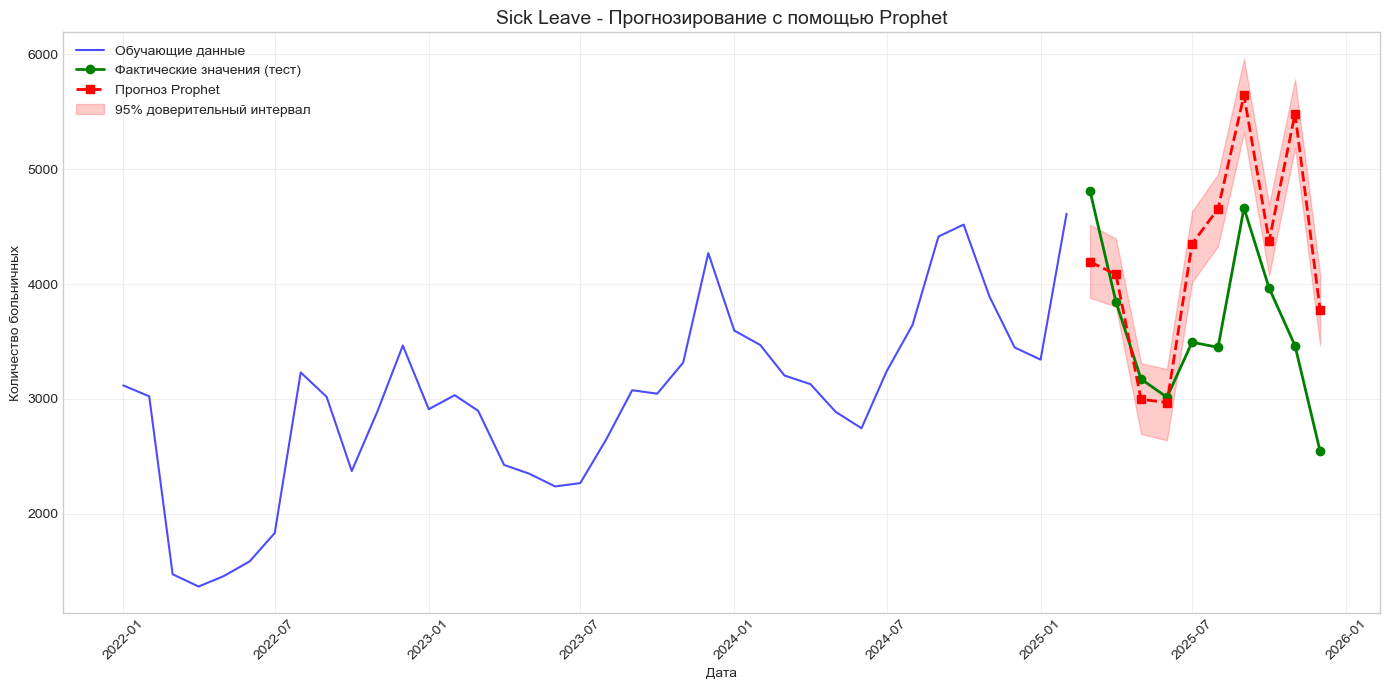


ПРОГНОЗ НА 12 МЕСЯЦЕВ ВПЕРЕД


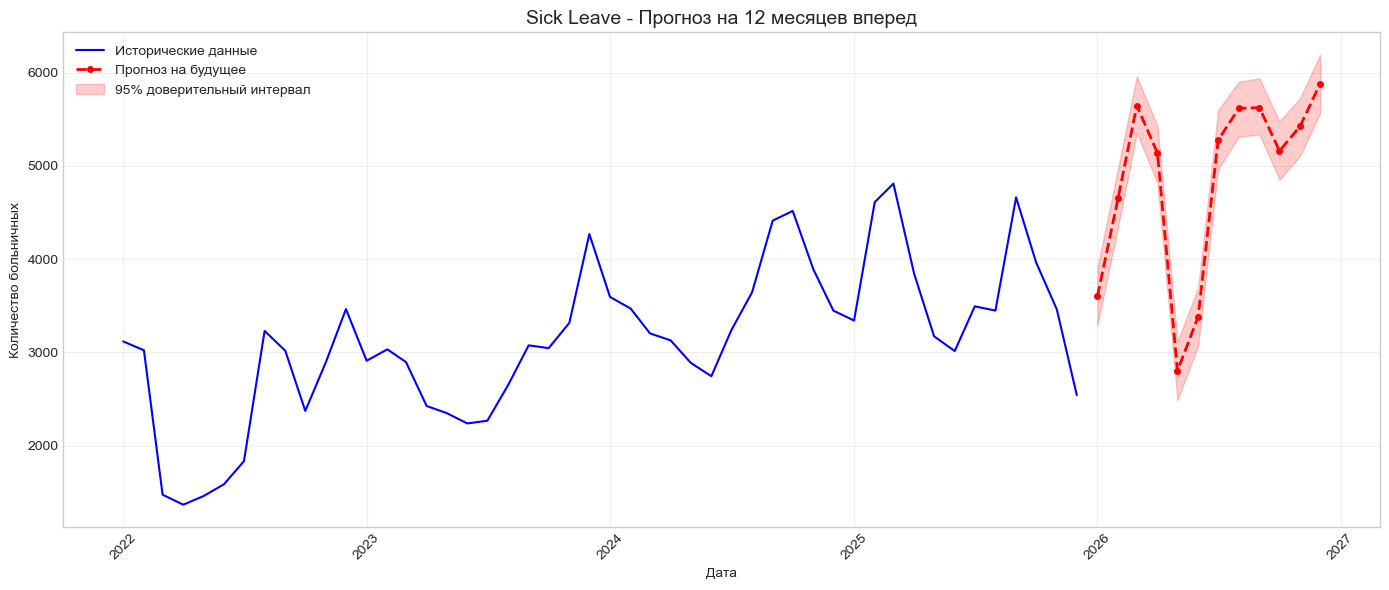

23:33:09 - cmdstanpy - INFO - Chain [1] start processing



📊 Прогноз на будущие периоды:
  Месяц  Прогноз  Нижняя граница  Верхняя граница
2026-01   3603.0          3293.0           3911.0
2026-02   4656.0          4347.0           4976.0
2026-03   5647.0          5352.0           5959.0
2026-04   5138.0          4815.0           5428.0
2026-05   2803.0          2487.0           3120.0
2026-06   3383.0          3071.0           3693.0
2026-07   5277.0          4965.0           5595.0
2026-08   5617.0          5311.0           5903.0
2026-09   5624.0          5336.0           5938.0
2026-10   5160.0          4851.0           5475.0
2026-11   5425.0          5107.0           5728.0
2026-12   5882.0          5566.0           6190.0

ПРОГНОЗ ДЛЯ VACATION НА 12 МЕСЯЦЕВ


23:33:09 - cmdstanpy - INFO - Chain [1] done processing


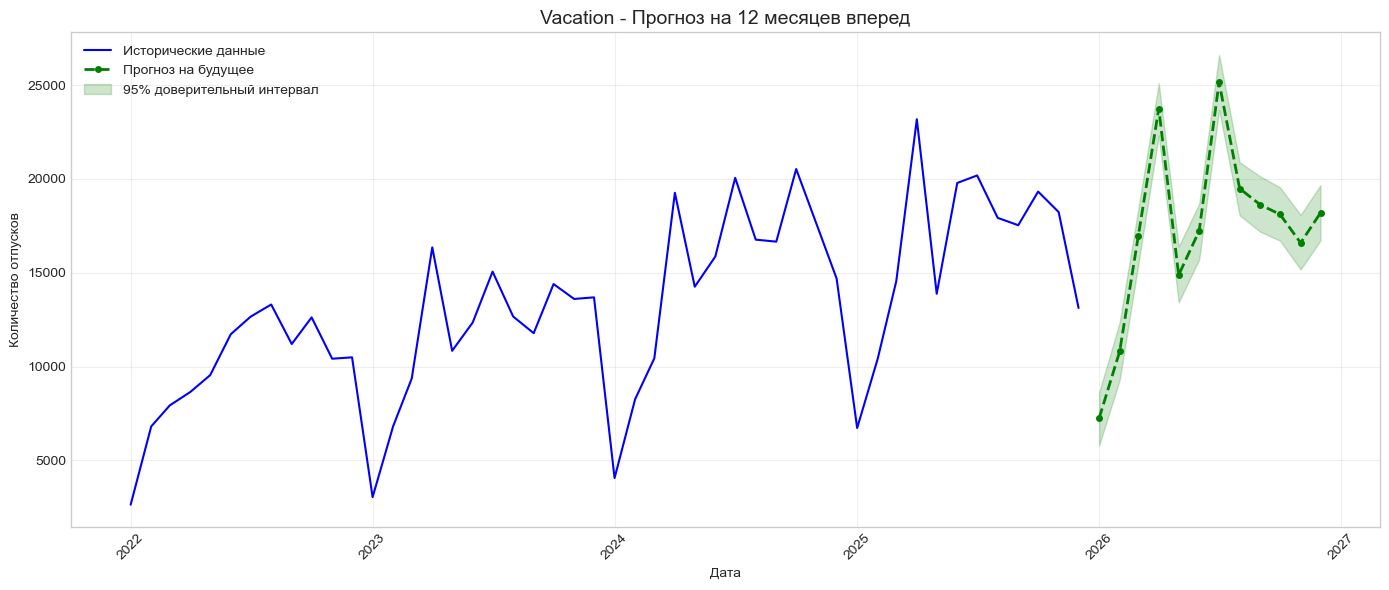


📊 Прогноз Vacation на будущие периоды:
  2026-01: 7245 (от 5795 до 8626)
  2026-02: 10806 (от 9289 до 12366)
  2026-03: 16933 (от 15407 до 18377)
  2026-04: 23749 (от 22318 до 25099)
  2026-05: 14881 (от 13414 до 16396)
  2026-06: 17233 (от 15719 до 18678)
  2026-07: 25159 (от 23667 до 26611)
  2026-08: 19487 (от 18057 до 20888)
  2026-09: 18627 (от 17187 до 20138)
  2026-10: 18109 (от 16707 до 19549)
  2026-11: 16592 (от 15172 до 18081)
  2026-12: 18191 (от 16727 до 19672)

✅ Все прогнозы успешно выполнены!


In [166]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ PROPHET (SICK LEAVE)
# ==================================================

# ВАЖНО: Убедимся, что df имеет колонку 'Time' как индекс или как колонку
# Если 'Time' - это индекс, сбрасываем его в колонку
if 'Time' not in df.columns:
    df = df.reset_index()
    df = df.rename(columns={'index': 'Time'})
    # Если после reset_index колонка называется 'index', переименовываем
    if 'index' in df.columns:
        df = df.rename(columns={'index': 'Time'})

# Создаем копию данных для Sick Leave
df_sick = df[['Time', 'Sick Leave']].copy()

# Переименовываем колонки как требует Prophet
df_sick = df_sick.rename(columns={'Time': 'ds', 'Sick Leave': 'y'})

# Убеждаемся, что даты в правильном формате
df_sick['ds'] = pd.to_datetime(df_sick['ds'])

# ==================================================
# 2. ПРОВЕРКА И ОБРАБОТКА ПРОБЛЕМНЫХ ЗНАЧЕНИЙ
# ==================================================

print("=" * 50)
print("АНАЛИЗ ДАННЫХ SICK LEAVE")
print("=" * 50)

# Проверяем наличие пропусков
print(f"Пропуски (NaN): {df_sick['y'].isna().sum()}")
print(f"Нулевые значения: {(df_sick['y'] == 0).sum()}")
print(f"Отрицательные значения: {(df_sick['y'] < 0).sum()}")

# Статистика по данным
print(f"\nСтатистика:")
print(f"  Минимум: {df_sick['y'].min()}")
print(f"  Максимум: {df_sick['y'].max()}")
print(f"  Среднее: {df_sick['y'].mean():.2f}")
print(f"  Медиана: {df_sick['y'].median():.2f}")

# ==================================================
# 3. ОБРАБОТКА НУЛЕВЫХ ЗНАЧЕНИЙ (КЛЮЧЕВОЙ МОМЕНТ!)
# ==================================================

# Prophet не любит нули, особенно если их много.
df_sick_processed = df_sick.copy()
if (df_sick_processed['y'] == 0).any():
    print(f"\n⚠️ Обнаружены нулевые значения. Добавляем маленькую константу...")
    epsilon = 1e-6  # Очень маленькое число
    df_sick_processed['y'] = df_sick_processed['y'].replace(0, epsilon)

print(f"После обработки нулей: мин={df_sick_processed['y'].min():.6f}")

# ==================================================
# 4. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ==================================================

train_size = int(len(df_sick_processed) * 0.8)

train_df = df_sick_processed.iloc[:train_size].copy()
test_df = df_sick_processed.iloc[train_size:].copy()

print(f"\nОбучающая выборка: {len(train_df)} наблюдений")
print(f"Тестовая выборка: {len(test_df)} наблюдений")

# ==================================================
# 5. ОБУЧЕНИЕ МОДЕЛИ PROPHET (С НАСТРОЙКАМИ ДЛЯ SICK LEAVE)
# ==================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5.0,
    interval_width=0.95,
)

# Добавляем дополнительные сезонности
model.add_seasonality(name='monthly', period=12, fourier_order=5)

# Обучаем модель
model.fit(train_df)

print("\n✅ Модель Prophet для Sick Leave успешно обучена!")

# ==================================================
# 6. ПРОГНОЗИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ
# ==================================================

# Создаем датафрейм с датами для прогноза
future_dates = test_df['ds'].copy()
future = pd.DataFrame({'ds': future_dates})

# Делаем прогноз
forecast = model.predict(future)

# Извлекаем предсказанные значения
predictions = forecast.set_index('ds')['yhat']
lower_bound = forecast.set_index('ds')['yhat_lower']
upper_bound = forecast.set_index('ds')['yhat_upper']

# ==================================================
# 7. ОЦЕНКА КАЧЕСТВА ПРОГНОЗА
# ==================================================

def calculate_metrics(y_true, y_pred):
    """Расчет метрик качества прогноза"""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    if len(y_true_clean) == 0:
        return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}
    
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    
    # MAPE (избегаем деления на ноль)
    y_true_nonzero = y_true_clean[y_true_clean != 0]
    y_pred_nonzero = y_pred_clean[y_true_clean != 0]
    if len(y_true_nonzero) > 0:
        mape = np.mean(np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)) * 100
    else:
        mape = np.nan
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Получаем фактические значения тестовой выборки
y_true = test_df.set_index('ds')['y']

# Расчет метрик
metrics = calculate_metrics(y_true, predictions)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ SICK LEAVE")
print("=" * 50)
print(f"MAE: {metrics['MAE']:.2f}")
print(f"RMSE: {metrics['RMSE']:.2f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")

# ==================================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==================================================

plt.figure(figsize=(14, 7))

# График обучающих данных
plt.plot(train_df['ds'], train_df['y'], 
         label='Обучающие данные', color='blue', linewidth=1.5, alpha=0.7)

# График тестовых данных
plt.plot(test_df['ds'], test_df['y'], 
         label='Фактические значения (тест)', color='green', linewidth=2, marker='o')

# График предсказаний
plt.plot(predictions.index, predictions, 
         label='Прогноз Prophet', color='red', linewidth=2, linestyle='--', marker='s')

# Доверительный интервал
plt.fill_between(predictions.index, lower_bound, upper_bound, 
                  color='red', alpha=0.2, label='95% доверительный интервал')

plt.title('Sick Leave - Прогнозирование с помощью Prophet', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество больничных')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==================================================
# 9. ПРОГНОЗ НА БУДУЩИЕ 12 МЕСЯЦЕВ
# ==================================================

print("\n" + "=" * 50)
print("ПРОГНОЗ НА 12 МЕСЯЦЕВ ВПЕРЕД")
print("=" * 50)

# Определяем последнюю дату в данных (используем ds, а не Time!)
last_date = df_sick_processed['ds'].max()

# Прогноз на следующие 12 месяцев
future_months = 12
future_dates_future = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_months,
    freq='MS'
)

future_future = pd.DataFrame({'ds': future_dates_future})
forecast_future = model.predict(future_future)

# Визуализация прогноза на будущее
plt.figure(figsize=(14, 6))
plt.plot(df_sick_processed['ds'], df_sick_processed['y'], 
         label='Исторические данные', color='blue', linewidth=1.5)
plt.plot(forecast_future['ds'], forecast_future['yhat'], 
         label='Прогноз на будущее', color='red', linewidth=2, linestyle='--', marker='o', markersize=4)
plt.fill_between(forecast_future['ds'], 
                  forecast_future['yhat_lower'], 
                  forecast_future['yhat_upper'], 
                  color='red', alpha=0.2, label='95% доверительный интервал')
plt.title('Sick Leave - Прогноз на 12 месяцев вперед', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество больничных')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вывод прогноза в таблицу
print("\n📊 Прогноз на будущие периоды:")
forecast_table = []
for i, row in forecast_future.iterrows():
    forecast_table.append({
        'Месяц': row['ds'].strftime('%Y-%m'),
        'Прогноз': round(row['yhat'], 0),
        'Нижняя граница': round(row['yhat_lower'], 0),
        'Верхняя граница': round(row['yhat_upper'], 0)
    })

forecast_df = pd.DataFrame(forecast_table)
print(forecast_df.to_string(index=False))

# ==================================================
# 10. ПРОГНОЗ ДЛЯ VACATION (АНАЛОГИЧНО)
# ==================================================

print("\n" + "=" * 50)
print("ПРОГНОЗ ДЛЯ VACATION НА 12 МЕСЯЦЕВ")
print("=" * 50)

# Подготовка данных для Vacation
df_vac = df[['Time', 'Vacation']].copy()
df_vac = df_vac.rename(columns={'Time': 'ds', 'Vacation': 'y'})
df_vac['ds'] = pd.to_datetime(df_vac['ds'])

# Обучение модели для Vacation
model_vac = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95,
)
model_vac.add_seasonality(name='monthly', period=12, fourier_order=5)
model_vac.fit(df_vac)

# Прогноз на 12 месяцев
last_date_vac = df_vac['ds'].max()
future_dates_vac = pd.date_range(
    start=last_date_vac + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)
future_vac = pd.DataFrame({'ds': future_dates_vac})
forecast_future_vac = model_vac.predict(future_vac)

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(df_vac['ds'], df_vac['y'], 
         label='Исторические данные', color='blue', linewidth=1.5)
plt.plot(forecast_future_vac['ds'], forecast_future_vac['yhat'], 
         label='Прогноз на будущее', color='green', linewidth=2, linestyle='--', marker='o', markersize=4)
plt.fill_between(forecast_future_vac['ds'], 
                  forecast_future_vac['yhat_lower'], 
                  forecast_future_vac['yhat_upper'], 
                  color='green', alpha=0.2, label='95% доверительный интервал')
plt.title('Vacation - Прогноз на 12 месяцев вперед', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество отпусков')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вывод прогноза Vacation
print("\n📊 Прогноз Vacation на будущие периоды:")
for i, row in forecast_future_vac.iterrows():
    print(f"  {row['ds'].strftime('%Y-%m')}: {row['yhat']:.0f} "
          f"(от {row['yhat_lower']:.0f} до {row['yhat_upper']:.0f})")

print("\n✅ Все прогнозы успешно выполнены!")


ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - Vacation
Создано признаков: 11
Количество наблюдений: 42
Признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month', 'quarter']

Обучающая выборка: 33 наблюдений
Тестовая выборка: 9 наблюдений

ОБУЧЕНИЕ МОДЕЛИ XGBOOST - Vacation
✅ Модель XGBoost для Vacation успешно обучена

📊 Важность признаков:
  quarter: 0.5890
  month: 0.2122
  rolling_mean_3: 0.0608
  rolling_std_3: 0.0363
  lag_3: 0.0266
  lag_6: 0.0258
  lag_4: 0.0173
  lag_5: 0.0137
  lag_1: 0.0077
  rolling_mean_6: 0.0059
  lag_2: 0.0048

РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ XGBOOST - Vacation
MAE (Средняя абсолютная ошибка): 2122.03
RMSE (Корень из среднеквадратичной ошибки): 2685.75
MAPE (Средняя абсолютная процентная ошибка): 11.38%


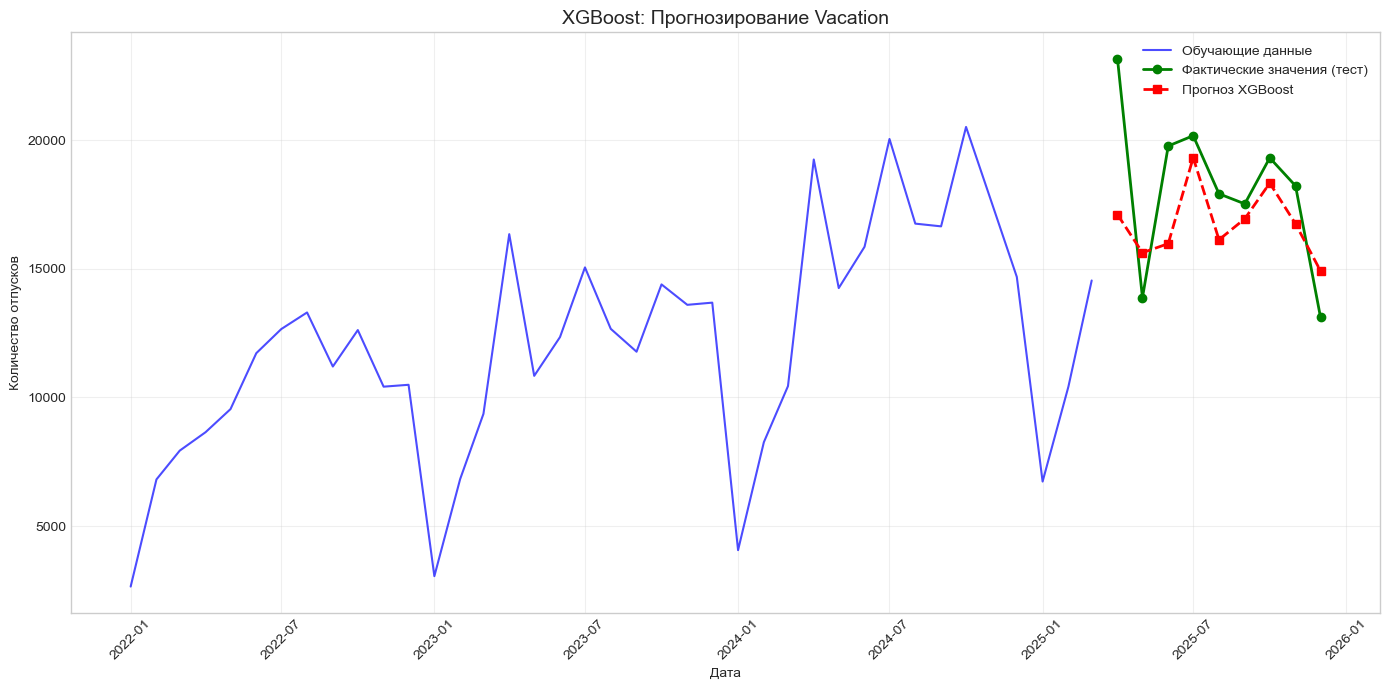

✅ Визуализация прогноза XGBoost для Vacation построена

СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ VACATION
Прогноз Prophet для Vacation не найден
XGBoost - RMSE: 2685.75, MAE: 2122.03


In [112]:
# ==================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - VACATION
# ==================================================

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - Vacation")
print("="*60)

# Функция для создания признаков на основе лагов (прошлых значений)
def create_lag_features(data, target_col, n_lags=6):
    """
    Создает датафрейм с лагами для XGBoost.
    
    Parameters:
    -----------
    data : DataFrame
        Исходные данные
    target_col : str
        Название целевой колонки
    n_lags : int
        Количество лагов (прошлых значений) для создания признаков
    
    Returns:
    --------
    X : DataFrame
        Матрица признаков (лаги)
    y : Series
        Целевая переменная
    dates : Index
        Индексы дат
    """
    df = data[[target_col]].copy()
    
    # Создаем лаги
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df[target_col].shift(i)
    
    # Добавляем скользящие средние (дополнительные признаки)
    df['rolling_mean_3'] = df[target_col].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df[target_col].shift(1).rolling(6).mean()
    df['rolling_std_3'] = df[target_col].shift(1).rolling(3).std()
    
    # Добавляем признаки времени (месяц, сезон)
    df['month'] = data.index.month
    df['quarter'] = data.index.quarter
    
    # Удаляем строки с NaN
    df = df.dropna()
    
    # Целевая переменная - текущее значение
    y = df[target_col]
    
    # Признаки - все колонки кроме целевой
    X = df.drop(columns=[target_col])
    
    return X, y, df.index

# Создаем признаки для Vacation
n_lags = 6  # Используем 6 прошлых месяцев для прогноза

X_vac, y_vac, dates_vac = create_lag_features(df, 'Vacation', n_lags=n_lags)

print(f"Создано признаков: {X_vac.shape[1]}")
print(f"Количество наблюдений: {len(X_vac)}")
print(f"Признаки: {list(X_vac.columns)}")

# ==================================================
# РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ==================================================

# Разделение (80% обучение, 20% тест)
train_size_xgb = int(len(X_vac) * 0.8)

X_train_vac = X_vac.iloc[:train_size_xgb]
X_test_vac = X_vac.iloc[train_size_xgb:]
y_train_vac = y_vac.iloc[:train_size_xgb]
y_test_vac = y_vac.iloc[train_size_xgb:]
dates_train_vac = dates_vac[:train_size_xgb]
dates_test_vac = dates_vac[train_size_xgb:]

print(f"\nОбучающая выборка: {len(X_train_vac)} наблюдений")
print(f"Тестовая выборка: {len(X_test_vac)} наблюдений")

# ==================================================
# МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (ВАЖНО ДЛЯ XGBOOST)
# ==================================================

# XGBoost не требует масштабирования, но это может помочь
scaler_vac = StandardScaler()
X_train_vac_scaled = scaler_vac.fit_transform(X_train_vac)
X_test_vac_scaled = scaler_vac.transform(X_test_vac)

# Преобразуем обратно в DataFrame для удобства
X_train_vac_scaled = pd.DataFrame(X_train_vac_scaled, 
                                   columns=X_train_vac.columns, 
                                   index=X_train_vac.index)
X_test_vac_scaled = pd.DataFrame(X_test_vac_scaled, 
                                  columns=X_test_vac.columns, 
                                  index=X_test_vac.index)

# ==================================================
# ОБУЧЕНИЕ МОДЕЛИ XGBOOST
# ==================================================

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ XGBOOST - Vacation")
print("="*60)

# Создание и обучение модели XGBoost
model_xgb_vac = xgb.XGBRegressor(
    n_estimators=200,           # количество деревьев
    max_depth=6,                # максимальная глубина дерева
    learning_rate=0.05,         # скорость обучения
    subsample=0.8,              # доля выборки для каждого дерева
    colsample_bytree=0.8,       # доля признаков для каждого дерева
    random_state=42,
    early_stopping_rounds=20,   # остановка при отсутствии улучшений
    eval_metric='mae'           # метрика для оценки
)

# Обучение модели
model_xgb_vac.fit(
    X_train_vac_scaled, 
    y_train_vac,
    eval_set=[(X_test_vac_scaled, y_test_vac)],
    verbose=False
)

print("✅ Модель XGBoost для Vacation успешно обучена")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train_vac.columns,
    'importance': model_xgb_vac.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Важность признаков:")
for _, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# ==================================================
# ПРОГНОЗИРОВАНИЕ
# ==================================================

# Прогнозирование на тестовой выборке
pred_xgb_vac = model_xgb_vac.predict(X_test_vac_scaled)

# ==================================================
# ОЦЕНКА КАЧЕСТВА
# ==================================================

def calculate_metrics(y_true, y_pred):
    """Расчет метрик качества прогноза"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

metrics_xgb_vac = calculate_metrics(y_test_vac, pred_xgb_vac)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ XGBOOST - Vacation")
print("="*60)
print(f"MAE (Средняя абсолютная ошибка): {metrics_xgb_vac['MAE']:.2f}")
print(f"RMSE (Корень из среднеквадратичной ошибки): {metrics_xgb_vac['RMSE']:.2f}")
print(f"MAPE (Средняя абсолютная процентная ошибка): {metrics_xgb_vac['MAPE']:.2f}%")

# ==================================================
# ВИЗУАЛИЗАЦИЯ
# ==================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Обучающие данные (используем original df для полного ряда)
# Находим даты для обучающей выборки
train_dates_full = df[df['Vacation'].notna()].index[:train_size_xgb + n_lags]

ax.plot(train_dates_full, train_dates_full.map(df['Vacation']), 
        label='Обучающие данные', color='blue', linewidth=1.5, alpha=0.7)

# Тестовые данные
ax.plot(dates_test_vac, y_test_vac, 
        label='Фактические значения (тест)', color='green', linewidth=2, marker='o')

# Прогноз
ax.plot(dates_test_vac, pred_xgb_vac, 
        label='Прогноз XGBoost', color='red', linewidth=2, linestyle='--', marker='s')

ax.set_title('XGBoost: Прогнозирование Vacation', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество отпусков')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Визуализация прогноза XGBoost для Vacation построена")

# ==================================================
# СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ (если есть)
# ==================================================

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ VACATION")
print("="*60)

try:
    # Если есть прогноз от Prophet для Vacation
    if 'pred_prophet_vac' in dir():
        metrics_prophet = calculate_metrics(y_test_vac, pred_prophet_vac)
        print(f"Prophet - RMSE: {metrics_prophet['RMSE']:.2f}, MAE: {metrics_prophet['MAE']:.2f}")
except:
    print("Прогноз Prophet для Vacation не найден")

print(f"XGBoost - RMSE: {metrics_xgb_vac['RMSE']:.2f}, MAE: {metrics_xgb_vac['MAE']:.2f}")


ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - Sick Leave
Создано признаков: 11
Количество наблюдений: 42
Признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month', 'quarter']

АНАЛИЗ ДАННЫХ SICK LEAVE
Статистика целевой переменной:
  Минимум: 1834.00
  Максимум: 4810.00
  Среднее: 3282.29
  Медиана: 3217.50
  Стандартное отклонение: 701.66

Верхний перцентиль (95%): 4606.30
Количество значений выше 4606.30: 3

Обучающая выборка: 33 наблюдений
Тестовая выборка: 9 наблюдений

ОБУЧЕНИЕ МОДЕЛИ XGBOOST - Sick Leave
✅ Модель XGBoost для Sick Leave успешно обучена

📊 Важность признаков (Sick Leave):
  rolling_mean_3: 0.3216
  lag_1: 0.1315
  lag_6: 0.0820
  rolling_mean_6: 0.0738
  quarter: 0.0732
  month: 0.0695
  lag_5: 0.0637
  lag_3: 0.0553
  lag_2: 0.0510
  rolling_std_3: 0.0411
  lag_4: 0.0371

РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ XGBOOST - Sick Leave
MAE (Средняя абсолютная ошибка): 359.57
RMSE (Корень из среднеквадратичной ошибки): 435.18
M

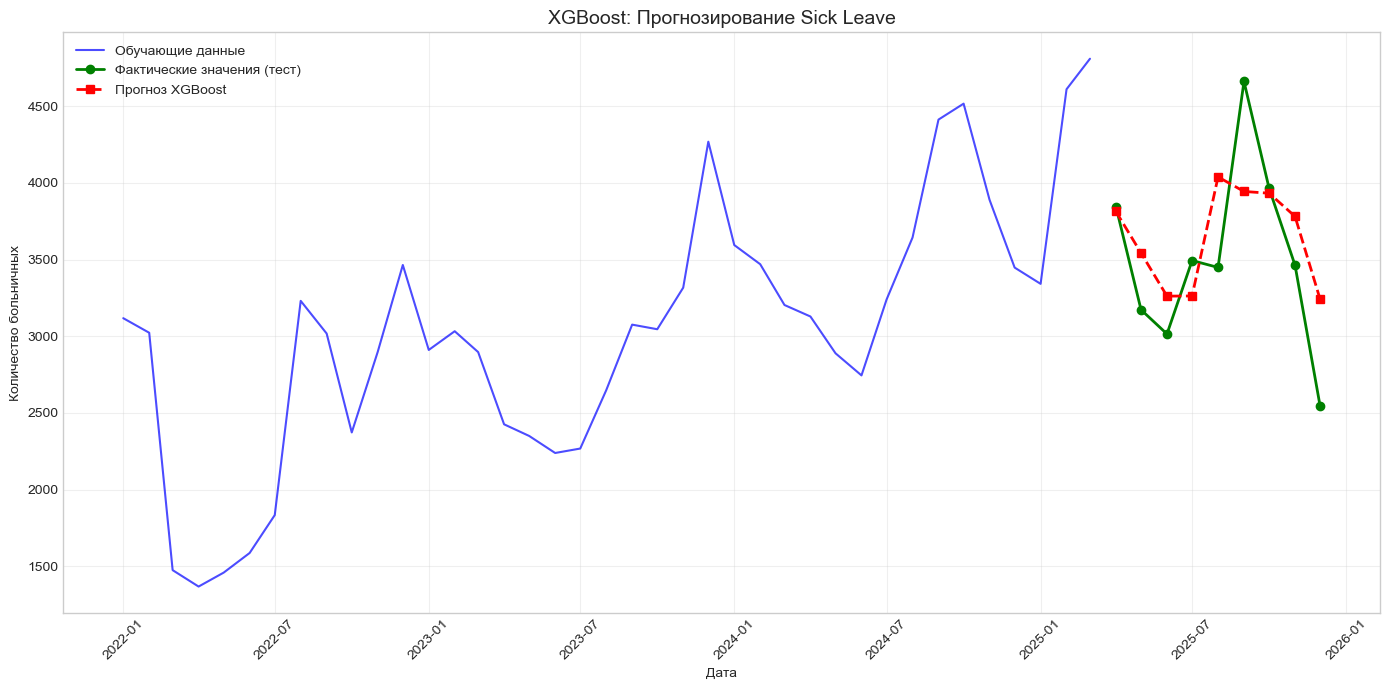

✅ Визуализация прогноза XGBoost для Sick Leave построена

ПРОГНОЗ НА СЛЕДУЮЩИЙ МЕСЯЦ (Sick Leave)
Последняя дата в данных: 2025-12
Прогноз на 2026-01: 3232

СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ SICK LEAVE
Прогноз Prophet для Sick Leave не найден
XGBoost - RMSE: 435.18, MAE: 359.57


In [113]:
# ==================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - SICK LEAVE
# ==================================================

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ XGBOOST - Sick Leave")
print("="*60)

# Функция для создания признаков на основе лагов (прошлых значений)
def create_lag_features(data, target_col, n_lags=6):
    """
    Создает датафрейм с лагами для XGBoost.
    
    Parameters:
    -----------
    data : DataFrame
        Исходные данные
    target_col : str
        Название целевой колонки
    n_lags : int
        Количество лагов (прошлых значений) для создания признаков
    
    Returns:
    --------
    X : DataFrame
        Матрица признаков (лаги)
    y : Series
        Целевая переменная
    dates : Index
        Индексы дат
    """
    df = data[[target_col]].copy()
    
    # Создаем лаги
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df[target_col].shift(i)
    
    # Добавляем скользящие средние (дополнительные признаки)
    df['rolling_mean_3'] = df[target_col].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df[target_col].shift(1).rolling(6).mean()
    df['rolling_std_3'] = df[target_col].shift(1).rolling(3).std()
    
    # Добавляем признаки времени (месяц, сезон)
    df['month'] = data.index.month
    df['quarter'] = data.index.quarter
    
    # Удаляем строки с NaN
    df = df.dropna()
    
    # Целевая переменная - текущее значение
    y = df[target_col]
    
    # Признаки - все колонки кроме целевой
    X = df.drop(columns=[target_col])
    
    return X, y, df.index

# Создаем признаки для Sick Leave
n_lags = 6  # Используем 6 прошлых месяцев для прогноза

X_sick, y_sick, dates_sick = create_lag_features(df, 'Sick Leave', n_lags=n_lags)

print(f"Создано признаков: {X_sick.shape[1]}")
print(f"Количество наблюдений: {len(X_sick)}")
print(f"Признаки: {list(X_sick.columns)}")

# ==================================================
# ОБРАБОТКА ВЫБРОСОВ И АНОМАЛИЙ (ДЛЯ SICK LEAVE)
# ==================================================

# Проверяем статистику целевой переменной
print("\n" + "="*60)
print("АНАЛИЗ ДАННЫХ SICK LEAVE")
print("="*60)

print(f"Статистика целевой переменной:")
print(f"  Минимум: {y_sick.min():.2f}")
print(f"  Максимум: {y_sick.max():.2f}")
print(f"  Среднее: {y_sick.mean():.2f}")
print(f"  Медиана: {y_sick.median():.2f}")
print(f"  Стандартное отклонение: {y_sick.std():.2f}")

# Опционально: ограничение выбросов (95-й перцентиль)
upper_limit = y_sick.quantile(0.95)
print(f"\nВерхний перцентиль (95%): {upper_limit:.2f}")
print(f"Количество значений выше {upper_limit:.2f}: {(y_sick > upper_limit).sum()}")

# Можно ограничить выбросы (раскомментировать при необходимости)
# y_sick = y_sick.clip(upper=y_sick.quantile(0.95))
# X_sick = X_sick[y_sick.notna()]

# ==================================================
# РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ==================================================

# Разделение (80% обучение, 20% тест)
train_size_xgb = int(len(X_sick) * 0.8)

X_train_sick = X_sick.iloc[:train_size_xgb]
X_test_sick = X_sick.iloc[train_size_xgb:]
y_train_sick = y_sick.iloc[:train_size_xgb]
y_test_sick = y_sick.iloc[train_size_xgb:]
dates_train_sick = dates_sick[:train_size_xgb]
dates_test_sick = dates_sick[train_size_xgb:]

print(f"\nОбучающая выборка: {len(X_train_sick)} наблюдений")
print(f"Тестовая выборка: {len(X_test_sick)} наблюдений")

# ==================================================
# МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
# ==================================================

scaler_sick = StandardScaler()
X_train_sick_scaled = scaler_sick.fit_transform(X_train_sick)
X_test_sick_scaled = scaler_sick.transform(X_test_sick)

# Преобразуем обратно в DataFrame для удобства
X_train_sick_scaled = pd.DataFrame(X_train_sick_scaled, 
                                    columns=X_train_sick.columns, 
                                    index=X_train_sick.index)
X_test_sick_scaled = pd.DataFrame(X_test_sick_scaled, 
                                   columns=X_test_sick.columns, 
                                   index=X_test_sick.index)

# ==================================================
# ОБУЧЕНИЕ МОДЕЛИ XGBOOST (С ОПТИМИЗАЦИЕЙ ДЛЯ SICK LEAVE)
# ==================================================

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ XGBOOST - Sick Leave")
print("="*60)

# Для Sick Leave могут потребоваться другие параметры
model_xgb_sick = xgb.XGBRegressor(
    n_estimators=200,           # количество деревьев
    max_depth=5,                # немного меньше для избежания переобучения
    learning_rate=0.05,         # скорость обучения
    subsample=0.8,              # доля выборки для каждого дерева
    colsample_bytree=0.8,       # доля признаков для каждого дерева
    reg_alpha=0.1,              # L1 регуляризация
    reg_lambda=1.0,             # L2 регуляризация
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae'
)

# Обучение модели
model_xgb_sick.fit(
    X_train_sick_scaled, 
    y_train_sick,
    eval_set=[(X_test_sick_scaled, y_test_sick)],
    verbose=False
)

print("✅ Модель XGBoost для Sick Leave успешно обучена")

# Важность признаков
feature_importance_sick = pd.DataFrame({
    'feature': X_train_sick.columns,
    'importance': model_xgb_sick.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Важность признаков (Sick Leave):")
for _, row in feature_importance_sick.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# ==================================================
# ПРОГНОЗИРОВАНИЕ
# ==================================================

# Прогнозирование на тестовой выборке
pred_xgb_sick = model_xgb_sick.predict(X_test_sick_scaled)

# ==================================================
# ОЦЕНКА КАЧЕСТВА
# ==================================================

def calculate_metrics(y_true, y_pred):
    """Расчет метрик качества прогноза"""
    # Защита от вырожденных случаев
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MAPE (избегаем деления на ноль)
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

metrics_xgb_sick = calculate_metrics(y_test_sick, pred_xgb_sick)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРОГНОЗИРОВАНИЯ XGBOOST - Sick Leave")
print("="*60)
print(f"MAE (Средняя абсолютная ошибка): {metrics_xgb_sick['MAE']:.2f}")
print(f"RMSE (Корень из среднеквадратичной ошибки): {metrics_xgb_sick['RMSE']:.2f}")
if not np.isnan(metrics_xgb_sick['MAPE']):
    print(f"MAPE (Средняя абсолютная процентная ошибка): {metrics_xgb_sick['MAPE']:.2f}%")
else:
    print("MAPE: невозможно рассчитать (есть нулевые значения)")

# ==================================================
# ВИЗУАЛИЗАЦИЯ
# ==================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Обучающие данные
train_dates_full = df[df['Sick Leave'].notna()].index[:train_size_xgb + n_lags]

ax.plot(train_dates_full, train_dates_full.map(df['Sick Leave']), 
        label='Обучающие данные', color='blue', linewidth=1.5, alpha=0.7)

# Тестовые данные
ax.plot(dates_test_sick, y_test_sick, 
        label='Фактические значения (тест)', color='green', linewidth=2, marker='o')

# Прогноз
ax.plot(dates_test_sick, pred_xgb_sick, 
        label='Прогноз XGBoost', color='red', linewidth=2, linestyle='--', marker='s')

ax.set_title('XGBoost: Прогнозирование Sick Leave', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество больничных')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Визуализация прогноза XGBoost для Sick Leave построена")

# ==================================================
# ДОПОЛНИТЕЛЬНО: ПРОГНОЗ НА 1 ШАГ ВПЕРЕД (СЛЕДУЮЩИЙ МЕСЯЦ)
# ==================================================

print("\n" + "="*60)
print("ПРОГНОЗ НА СЛЕДУЮЩИЙ МЕСЯЦ (Sick Leave)")
print("="*60)

# Берем последние n_lags значений для прогноза
last_values = df['Sick Leave'].iloc[-(n_lags):].values

# Создаем признаки для прогноза
last_lags = {}
for i in range(1, n_lags + 1):
    last_lags[f'lag_{i}'] = last_values[-i] if i <= len(last_values) else last_values[0]

# Добавляем скользящие средние
last_lags['rolling_mean_3'] = np.mean(last_values[-3:]) if len(last_values) >= 3 else np.mean(last_values)
last_lags['rolling_mean_6'] = np.mean(last_values[-6:]) if len(last_values) >= 6 else np.mean(last_values)
last_lags['rolling_std_3'] = np.std(last_values[-3:]) if len(last_values) >= 3 else 0

# Добавляем временные признаки для следующего месяца
from datetime import timedelta
last_date = df.index[-1]
next_month = last_date + pd.DateOffset(months=1)
last_lags['month'] = next_month.month
last_lags['quarter'] = (next_month.month - 1) // 3 + 1

# Создаем DataFrame для прогноза
future_df = pd.DataFrame([last_lags])
future_df_scaled = scaler_sick.transform(future_df)

# Прогноз на следующий месяц
next_month_pred = model_xgb_sick.predict(future_df_scaled)[0]

print(f"Последняя дата в данных: {last_date.strftime('%Y-%m')}")
print(f"Прогноз на {next_month.strftime('%Y-%m')}: {next_month_pred:.0f}")

# ==================================================
# СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ SICK LEAVE
# ==================================================

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ SICK LEAVE")
print("="*60)

try:
    # Если есть прогноз от Prophet для Sick Leave
    if 'pred_prophet_sick' in locals():
        metrics_prophet = calculate_metrics(y_test_sick, pred_prophet_sick)
        print(f"Prophet - RMSE: {metrics_prophet['RMSE']:.2f}, MAE: {metrics_prophet['MAE']:.2f}")
    else:
        print("Прогноз Prophet для Sick Leave не найден")
except:
    print("Прогноз Prophet для Sick Leave не найден")

print(f"XGBoost - RMSE: {metrics_xgb_sick['RMSE']:.2f}, MAE: {metrics_xgb_sick['MAE']:.2f}")


ПРОГНОЗИРОВАНИЕ НА 12 МЕСЯЦЕВ ВПЕРЕД - XGBOOST

------------------------------------------------------------
XGBOOST - Прогноз Vacation на 12 месяцев
------------------------------------------------------------
Признаки Vacation: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month', 'quarter']
✅ Модель XGBoost для Vacation обучена
Прогнозный период: 2026-01 - 2026-12
Прогноз Vacation: [np.float32(7046.0), np.float32(10101.0), np.float32(11399.0), np.float32(14078.0), np.float32(13474.0), np.float32(13324.0), np.float32(12802.0), np.float32(12062.0), np.float32(11838.0), np.float32(12697.0), np.float32(12517.0), np.float32(12455.0)]

------------------------------------------------------------
XGBOOST - Прогноз Sick Leave на 12 месяцев
------------------------------------------------------------
Признаки Sick Leave: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', '

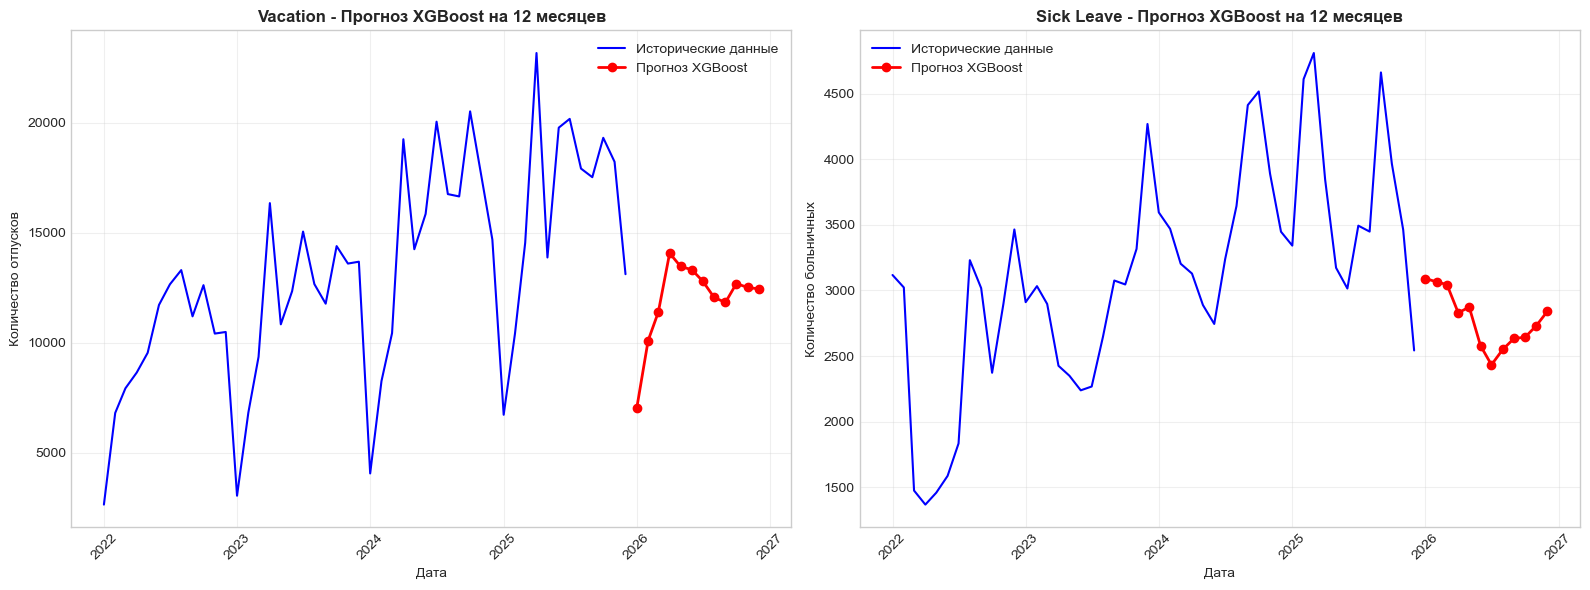


СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ XGBOOST НА 12 МЕСЯЦЕВ
  Месяц  Vacation (XGBoost)  Sick Leave (XGBoost)
2026-01              7046.0                3091.0
2026-02             10101.0                3065.0
2026-03             11399.0                3045.0
2026-04             14078.0                2830.0
2026-05             13474.0                2874.0
2026-06             13324.0                2580.0
2026-07             12802.0                2433.0
2026-08             12062.0                2550.0
2026-09             11838.0                2635.0
2026-10             12697.0                2643.0
2026-11             12517.0                2732.0
2026-12             12455.0                2840.0

✅ Прогнозы XGBoost успешно построены!


In [115]:
# ==================================================
# ПРОГНОЗ НА 12 МЕСЯЦЕВ ВПЕРЕД - XGBOOST (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ==================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("ПРОГНОЗИРОВАНИЕ НА 12 МЕСЯЦЕВ ВПЕРЕД - XGBOOST")
print("="*80)

# ==================================================
# ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ (С ФИКСИРОВАННЫМИ ИМЕНАМИ)
# ==================================================

def create_lag_features(data, target_col, n_lags=6):
    """
    Создает датафрейм с лагами для XGBoost.
    """
    df = data[[target_col]].copy()
    
    # Создаем лаги
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df[target_col].shift(i)
    
    # Добавляем скользящие средние
    df['rolling_mean_3'] = df[target_col].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df[target_col].shift(1).rolling(6).mean()
    df['rolling_std_3'] = df[target_col].shift(1).rolling(3).std()
    
    # Добавляем признаки времени
    df['month'] = data.index.month
    df['quarter'] = data.index.quarter
    
    # Заполняем NaN (для первых строк)
    df = df.fillna(method='bfill').fillna(0)
    
    # Целевая переменная - текущее значение
    y = df[target_col]
    
    # Признаки - все колонки кроме целевой
    X = df.drop(columns=[target_col])
    
    # Сохраняем порядок колонок для一致性
    feature_columns = X.columns.tolist()
    
    return X, y, feature_columns

# ==================================================
# VACATION
# ==================================================

print("\n" + "-"*60)
print("XGBOOST - Прогноз Vacation на 12 месяцев")
print("-"*60)

# Создаем признаки
n_lags = 6
X_vac, y_vac, vac_features = create_lag_features(df, 'Vacation', n_lags)

# Разделение на обучающую и тестовую
train_size = int(len(X_vac) * 0.8)
X_train_vac = X_vac.iloc[:train_size]
X_test_vac = X_vac.iloc[train_size:]
y_train_vac = y_vac.iloc[:train_size]
y_test_vac = y_vac.iloc[train_size:]

print(f"Признаки Vacation: {vac_features}")

# Масштабирование
scaler_vac = StandardScaler()
X_train_vac_scaled = scaler_vac.fit_transform(X_train_vac)
X_test_vac_scaled = scaler_vac.transform(X_test_vac)

# Обучение модели
model_xgb_vac = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae'
)

model_xgb_vac.fit(
    X_train_vac_scaled, y_train_vac,
    eval_set=[(X_test_vac_scaled, y_test_vac)],
    verbose=False
)

print("✅ Модель XGBoost для Vacation обучена")

# ==================================================
# ФУНКЦИЯ ДЛЯ РЕКУРСИВНОГО ПРОГНОЗИРОВАНИЯ (ИСПРАВЛЕННАЯ)
# ==================================================

def forecast_xgboost_future(model, scaler, df, target_col, feature_cols, n_lags=6, n_steps=12):
    """
    Рекурсивное прогнозирование на n_steps вперед.
    Ключевое исправление: строгое соблюдение порядка признаков.
    """
    # Берем последние n_lags значений
    last_values = df[target_col].iloc[-(n_lags):].values.tolist()
    
    predictions = []
    pred_dates = []
    
    # Сохраняем индексы колонок для проверки
    expected_cols = feature_cols
    
    for step in range(n_steps):
        # Создаем словарь признаков
        features = {}
        
        # Лаги
        for i in range(1, n_lags + 1):
            if len(last_values) >= i:
                features[f'lag_{i}'] = last_values[-i]
            else:
                features[f'lag_{i}'] = last_values[0] if last_values else 0
        
        # Скользящие средние
        if len(last_values) >= 3:
            features['rolling_mean_3'] = np.mean(last_values[-3:])
            features['rolling_std_3'] = np.std(last_values[-3:])
        else:
            features['rolling_mean_3'] = np.mean(last_values) if last_values else 0
            features['rolling_std_3'] = 0
        
        if len(last_values) >= 6:
            features['rolling_mean_6'] = np.mean(last_values[-6:])
        else:
            features['rolling_mean_6'] = np.mean(last_values) if last_values else 0
        
        # Временные признаки для прогнозируемой даты
        last_date = df.index[-1]
        next_date = last_date + pd.DateOffset(months=step + 1)
        features['month'] = next_date.month
        features['quarter'] = (next_date.month - 1) // 3 + 1
        
        # ВАЖНО: создаем DataFrame с колонками в правильном порядке
        features_df = pd.DataFrame([features])
        features_df = features_df[expected_cols]  # Переставляем колонки в нужном порядке
        
        # Проверяем, что все колонки на месте
        if list(features_df.columns) != expected_cols:
            raise ValueError(f"Несоответствие колонок: {features_df.columns} vs {expected_cols}")
        
        # Масштабируем
        features_scaled = scaler.transform(features_df)
        
        # Предсказываем
        pred = model.predict(features_scaled)[0]
        
        predictions.append(pred)
        pred_dates.append(next_date)
        
        # Добавляем предсказанное значение для следующего шага
        last_values.append(pred)
    
    return pred_dates, predictions

# Прогноз Vacation
future_dates_xgb_vac, pred_xgb_vac_future = forecast_xgboost_future(
    model_xgb_vac, scaler_vac, df, 'Vacation', vac_features, n_lags, n_steps=12
)

print(f"Прогнозный период: {future_dates_xgb_vac[0].strftime('%Y-%m')} - {future_dates_xgb_vac[-1].strftime('%Y-%m')}")
print(f"Прогноз Vacation: {[round(p, 0) for p in pred_xgb_vac_future]}")

# ==================================================
# SICK LEAVE
# ==================================================

print("\n" + "-"*60)
print("XGBOOST - Прогноз Sick Leave на 12 месяцев")
print("-"*60)

# Создаем признаки
X_sick, y_sick, sick_features = create_lag_features(df, 'Sick Leave', n_lags)

# Разделение
train_size = int(len(X_sick) * 0.8)
X_train_sick = X_sick.iloc[:train_size]
X_test_sick = X_sick.iloc[train_size:]
y_train_sick = y_sick.iloc[:train_size]
y_test_sick = y_sick.iloc[train_size:]

print(f"Признаки Sick Leave: {sick_features}")

# Масштабирование
scaler_sick = StandardScaler()
X_train_sick_scaled = scaler_sick.fit_transform(X_train_sick)
X_test_sick_scaled = scaler_sick.transform(X_test_sick)

# Обучение модели
model_xgb_sick = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae'
)

model_xgb_sick.fit(
    X_train_sick_scaled, y_train_sick,
    eval_set=[(X_test_sick_scaled, y_test_sick)],
    verbose=False
)

print("✅ Модель XGBoost для Sick Leave обучена")

# Прогноз Sick Leave
future_dates_xgb_sick, pred_xgb_sick_future = forecast_xgboost_future(
    model_xgb_sick, scaler_sick, df, 'Sick Leave', sick_features, n_lags, n_steps=12
)

print(f"Прогнозный период: {future_dates_xgb_sick[0].strftime('%Y-%m')} - {future_dates_xgb_sick[-1].strftime('%Y-%m')}")
print(f"Прогноз Sick Leave: {[round(p, 0) for p in pred_xgb_sick_future]}")

# ==================================================
# ВИЗУАЛИЗАЦИЯ
# ==================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График для Vacation
ax1.plot(df.index, df['Vacation'], label='Исторические данные', color='blue', linewidth=1.5)
ax1.plot(future_dates_xgb_vac, pred_xgb_vac_future, 
         label='Прогноз XGBoost', color='red', linewidth=2, marker='o', markersize=6)
ax1.set_title('Vacation - Прогноз XGBoost на 12 месяцев', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество отпусков')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# График для Sick Leave
ax2.plot(df.index, df['Sick Leave'], label='Исторические данные', color='blue', linewidth=1.5)
ax2.plot(future_dates_xgb_sick, pred_xgb_sick_future, 
         label='Прогноз XGBoost', color='red', linewidth=2, marker='o', markersize=6)
ax2.set_title('Sick Leave - Прогноз XGBoost на 12 месяцев', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Количество больничных')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==================================================
# СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ
# ==================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ XGBOOST НА 12 МЕСЯЦЕВ")
print("="*80)

summary_data = []
for i in range(12):
    summary_data.append({
        'Месяц': future_dates_xgb_vac[i].strftime('%Y-%m'),
        'Vacation (XGBoost)': round(pred_xgb_vac_future[i], 0),
        'Sick Leave (XGBoost)': round(pred_xgb_sick_future[i], 0)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n✅ Прогнозы XGBoost успешно построены!")

23:34:01 - cmdstanpy - INFO - Chain [1] start processing



ПРОГНОЗИРОВАНИЕ НА 12 МЕСЯЦЕВ ВПЕРЕД - PROPHET

------------------------------------------------------------
PROPHET - Прогноз Vacation на 12 месяцев
------------------------------------------------------------


23:34:01 - cmdstanpy - INFO - Chain [1] done processing
23:34:01 - cmdstanpy - INFO - Chain [1] start processing


✅ Модель Prophet для Vacation обучена
Прогнозный период: 2026-01 - 2026-12
Прогнозируемый максимум: 26772
Прогнозируемый минимум: 9512

------------------------------------------------------------
PROPHET - Прогноз Sick Leave на 12 месяцев
------------------------------------------------------------


23:34:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Модель Prophet для Sick Leave обучена
Прогнозный период: 2026-01 - 2026-12
Прогнозируемый максимум: 9290
Прогнозируемый минимум: 4115


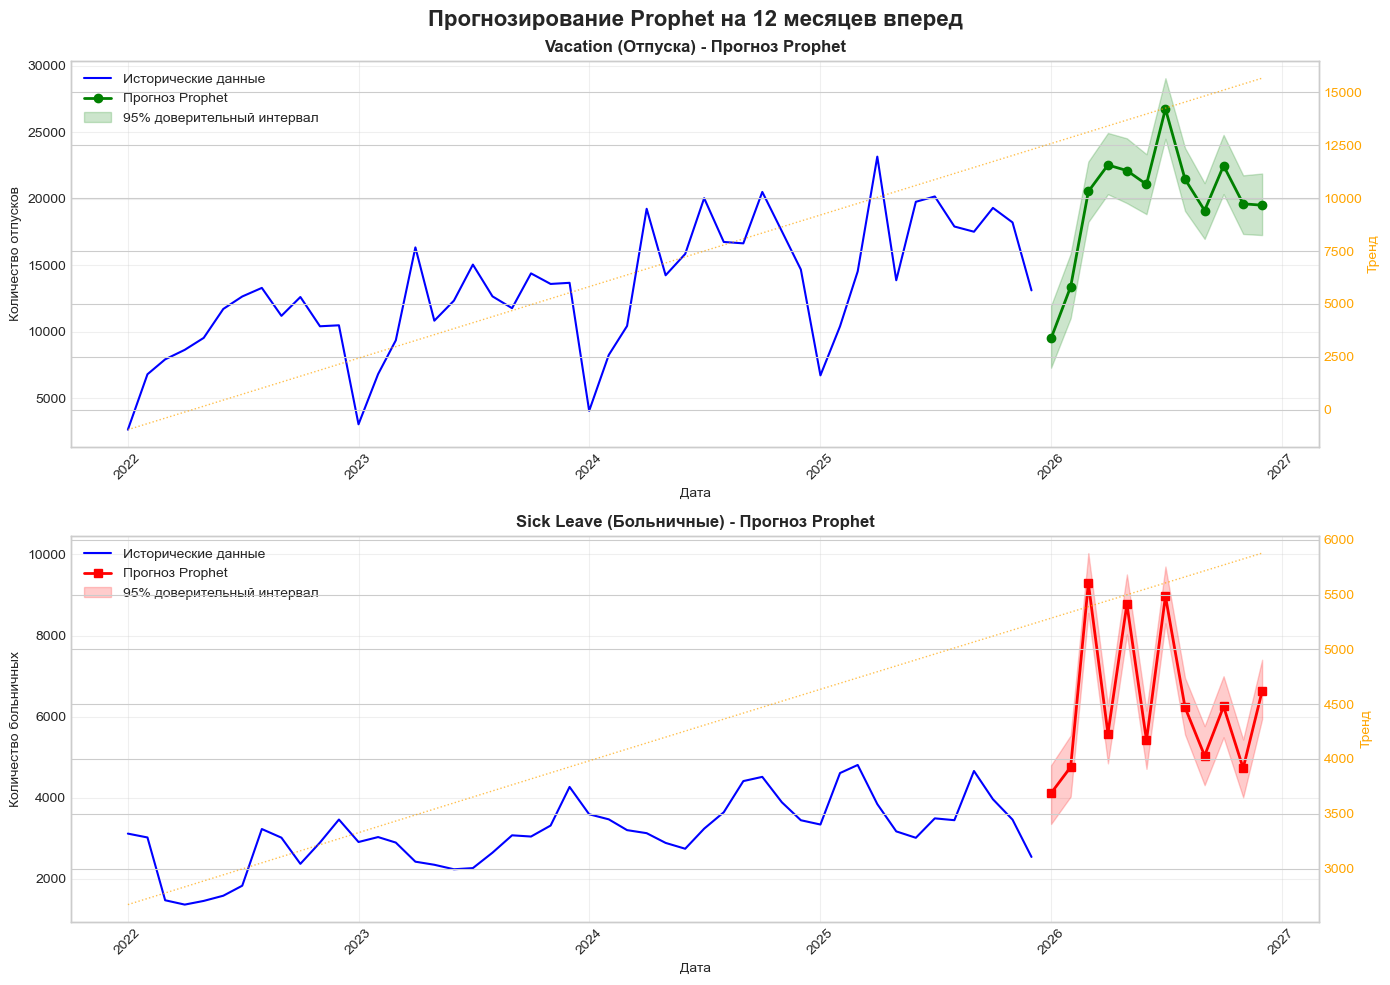

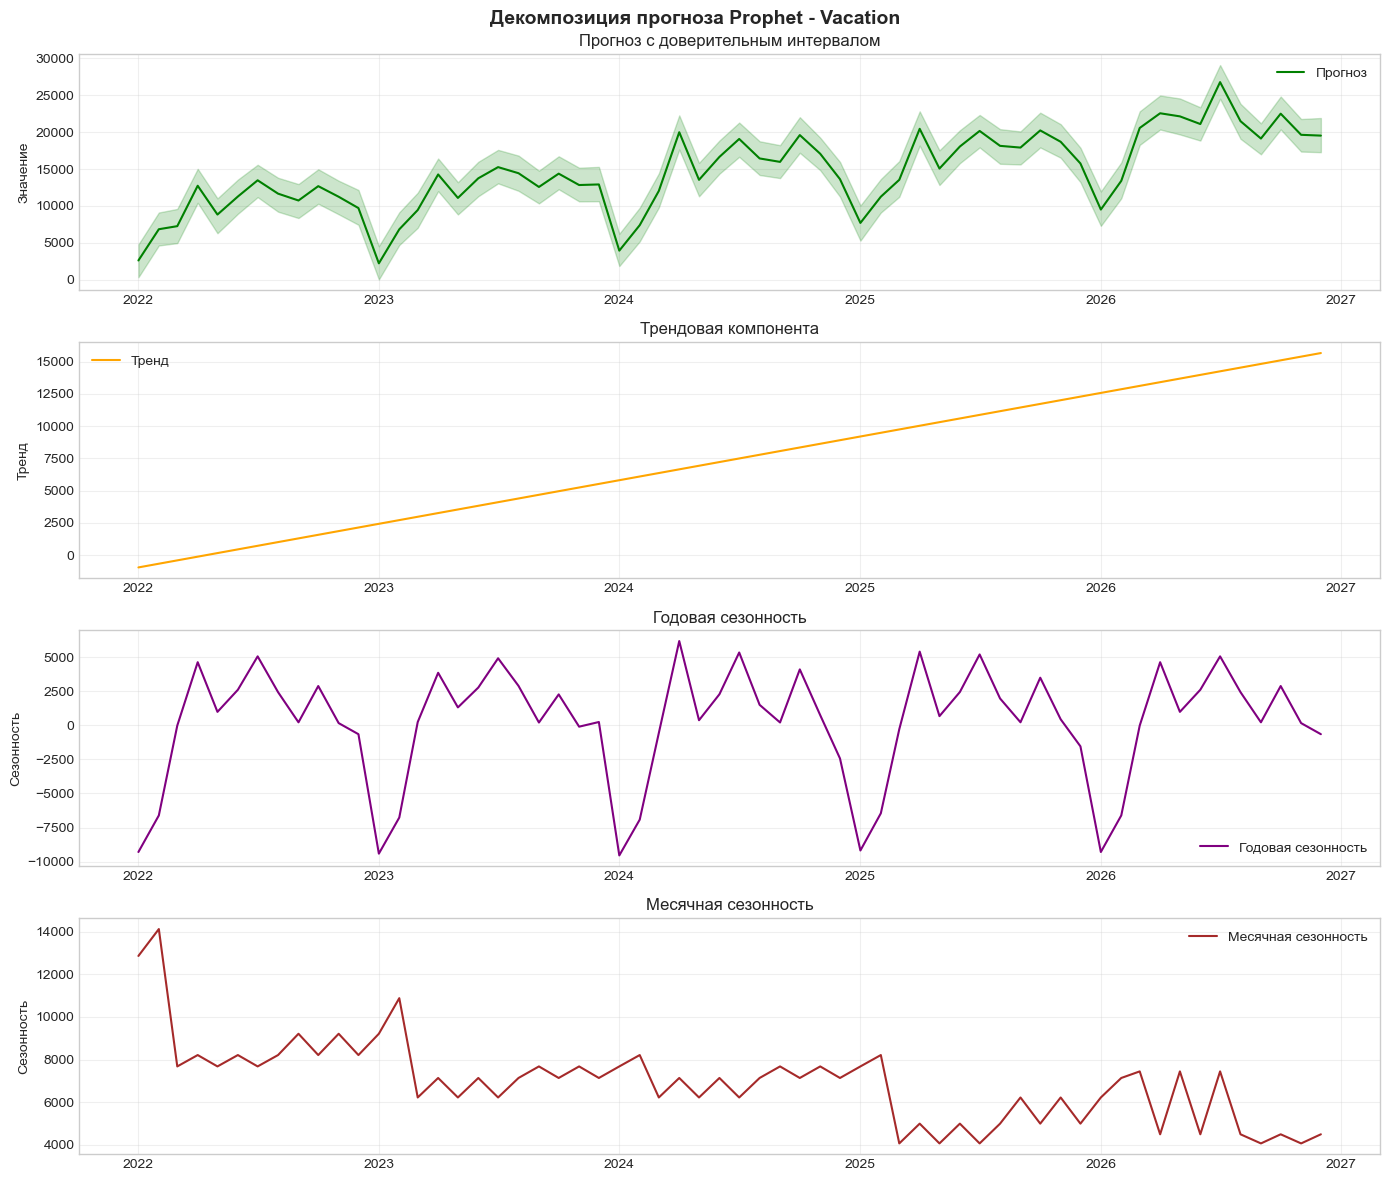


СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ PROPHET НА 12 МЕСЯЦЕВ
  Месяц  Vacation_Прогноз  Vacation_Нижняя  Vacation_Верхняя  Sick_Leave_Прогноз  Sick_Leave_Нижняя  Sick_Leave_Верхняя
2026-01            9512.0           7304.0           11968.0              4115.0             3355.0              4804.0
2026-02           13398.0          11033.0           15881.0              4760.0             4031.0              5537.0
2026-03           20562.0          18267.0           22810.0              9290.0             8560.0             10034.0
2026-04           22552.0          20354.0           24961.0              5583.0             4849.0              6275.0
2026-05           22133.0          19686.0           24557.0              8776.0             8029.0              9508.0
2026-06           21094.0          18853.0           23360.0              5418.0             4714.0              6151.0
2026-07           26772.0          24522.0           29084.0              8972.0             8304.0            

In [168]:
# ==================================================
# ПРОГНОЗ НА 12 МЕСЯЦЕВ ВПЕРЕД - PROPHET
# ==================================================

from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("ПРОГНОЗИРОВАНИЕ НА 12 МЕСЯЦЕВ ВПЕРЕД - PROPHET")
print("="*80)

# ==================================================
# 1. ПРОГНОЗ ДЛЯ VACATION (ОТПУСКА)
# ==================================================

print("\n" + "-"*60)
print("PROPHET - Прогноз Vacation на 12 месяцев")
print("-"*60)

# Подготовка данных для Prophet
df_prophet_vac = df[['Time', 'Vacation']].copy()
df_prophet_vac = df_prophet_vac.rename(columns={'Time': 'ds', 'Vacation': 'y'})

# Убеждаемся, что даты в правильном формате
df_prophet_vac['ds'] = pd.to_datetime(df_prophet_vac['ds'])

# Настройка и обучение модели Prophet
model_prophet_vac = Prophet(
    yearly_seasonality=True,      # годовая сезонность
    weekly_seasonality=False,     # отключаем недельную (у нас месячные данные)
    daily_seasonality=False,      # отключаем дневную
    seasonality_mode='additive',  # аддитивная сезонность
    changepoint_prior_scale=0.05, # чувствительность к изменениям тренда
    seasonality_prior_scale=10.0, # сила сезонности
    interval_width=0.95           # 95% доверительный интервал
)

# Добавляем дополнительную месячную сезонность
model_prophet_vac.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Обучение модели
model_prophet_vac.fit(df_prophet_vac)
print("✅ Модель Prophet для Vacation обучена")

# Создание датафрейма для прогноза на 12 месяцев
future_vac = model_prophet_vac.make_future_dataframe(periods=12, freq='MS')

# Прогнозирование
forecast_vac = model_prophet_vac.predict(future_vac)

# Извлекаем прогноз на будущие 12 месяцев
last_date = df_prophet_vac['ds'].max()
forecast_future_vac = forecast_vac[forecast_vac['ds'] > last_date].copy()

print(f"Прогнозный период: {forecast_future_vac['ds'].min().strftime('%Y-%m')} - {forecast_future_vac['ds'].max().strftime('%Y-%m')}")
print(f"Прогнозируемый максимум: {forecast_future_vac['yhat'].max():.0f}")
print(f"Прогнозируемый минимум: {forecast_future_vac['yhat'].min():.0f}")

# ==================================================
# 2. ПРОГНОЗ ДЛЯ SICK LEAVE (БОЛЬНИЧНЫЕ)
# ==================================================

print("\n" + "-"*60)
print("PROPHET - Прогноз Sick Leave на 12 месяцев")
print("-"*60)

# Подготовка данных для Prophet
df_prophet_sick = df[['Time', 'Sick Leave']].copy()
df_prophet_sick = df_prophet_sick.rename(columns={'Time': 'ds', 'Sick Leave': 'y'})

# Убеждаемся, что даты в правильном формате
df_prophet_sick['ds'] = pd.to_datetime(df_prophet_sick['ds'])

# Обработка нулевых значений (Prophet не любит нули)
if (df_prophet_sick['y'] == 0).any():
    print("⚠️ Обнаружены нулевые значения. Добавляем маленькую константу...")
    epsilon = 1e-6
    df_prophet_sick['y'] = df_prophet_sick['y'].replace(0, epsilon)

# Настройка и обучение модели Prophet для Sick Leave
model_prophet_sick = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5.0,   # меньшая сила сезонности для больничных
    interval_width=0.95
)

# Добавляем дополнительную месячную сезонность
model_prophet_sick.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Обучение модели
model_prophet_sick.fit(df_prophet_sick)
print("✅ Модель Prophet для Sick Leave обучена")

# Создание датафрейма для прогноза на 12 месяцев
future_sick = model_prophet_sick.make_future_dataframe(periods=12, freq='MS')

# Прогнозирование
forecast_sick = model_prophet_sick.predict(future_sick)

# Извлекаем прогноз на будущие 12 месяцев
forecast_future_sick = forecast_sick[forecast_sick['ds'] > last_date].copy()

print(f"Прогнозный период: {forecast_future_sick['ds'].min().strftime('%Y-%m')} - {forecast_future_sick['ds'].max().strftime('%Y-%m')}")
print(f"Прогнозируемый максимум: {forecast_future_sick['yhat'].max():.0f}")
print(f"Прогнозируемый минимум: {forecast_future_sick['yhat'].min():.0f}")

# ==================================================
# 3. ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ
# ==================================================

# Создаем фигуру с 2 подграфиками
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Прогнозирование Prophet на 12 месяцев вперед', fontsize=16, fontweight='bold')

# ==================================================
# График 1: Vacation - Prophet
# ==================================================
# Исторические данные
ax1.plot(df_prophet_vac['ds'], df_prophet_vac['y'], 
         label='Исторические данные', color='blue', linewidth=1.5)

# Прогноз Prophet (только будущий период)
ax1.plot(forecast_future_vac['ds'], forecast_future_vac['yhat'], 
         label='Прогноз Prophet', color='green', linewidth=2, marker='o', markersize=6)

# Доверительный интервал Prophet
ax1.fill_between(forecast_future_vac['ds'], 
                  forecast_future_vac['yhat_lower'], 
                  forecast_future_vac['yhat_upper'], 
                  color='green', alpha=0.2, label='95% доверительный интервал')

# Компоненты прогноза (тренд, сезонность) - опционально
ax1_twin = ax1.twinx()
ax1_twin.plot(forecast_vac['ds'], forecast_vac['trend'], 
              color='orange', linewidth=1, linestyle=':', alpha=0.7, label='Тренд')
ax1_twin.set_ylabel('Тренд', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')

ax1.set_title('Vacation (Отпуска) - Прогноз Prophet', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество отпусков')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# ==================================================
# График 2: Sick Leave - Prophet
# ==================================================
# Исторические данные
ax2.plot(df_prophet_sick['ds'], df_prophet_sick['y'], 
         label='Исторические данные', color='blue', linewidth=1.5)

# Прогноз Prophet (только будущий период)
ax2.plot(forecast_future_sick['ds'], forecast_future_sick['yhat'], 
         label='Прогноз Prophet', color='red', linewidth=2, marker='s', markersize=6)

# Доверительный интервал Prophet
ax2.fill_between(forecast_future_sick['ds'], 
                  forecast_future_sick['yhat_lower'], 
                  forecast_future_sick['yhat_upper'], 
                  color='red', alpha=0.2, label='95% доверительный интервал')

# Компоненты прогноза (тренд, сезонность) - опционально
ax2_twin = ax2.twinx()
ax2_twin.plot(forecast_sick['ds'], forecast_sick['trend'], 
              color='orange', linewidth=1, linestyle=':', alpha=0.7, label='Тренд')
ax2_twin.set_ylabel('Тренд', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')

ax2.set_title('Sick Leave (Больничные) - Прогноз Prophet', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Количество больничных')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==================================================
# 4. ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ КОМПОНЕНТОВ ПРОГНОЗА
# ==================================================

# Разложение прогноза на компоненты для Vacation
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Декомпозиция прогноза Prophet - Vacation', fontsize=14, fontweight='bold')

# Исходные данные + прогноз
axes[0].plot(forecast_vac['ds'], forecast_vac['yhat'], 
             label='Прогноз', color='green', linewidth=1.5)
axes[0].fill_between(forecast_vac['ds'], 
                      forecast_vac['yhat_lower'], 
                      forecast_vac['yhat_upper'], 
                      color='green', alpha=0.2)
axes[0].set_title('Прогноз с доверительным интервалом')
axes[0].set_ylabel('Значение')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Тренд
axes[1].plot(forecast_vac['ds'], forecast_vac['trend'], 
             label='Тренд', color='orange', linewidth=1.5)
axes[1].set_title('Трендовая компонента')
axes[1].set_ylabel('Тренд')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Годовая сезонность
axes[2].plot(forecast_vac['ds'], forecast_vac['yearly'], 
             label='Годовая сезонность', color='purple', linewidth=1.5)
axes[2].set_title('Годовая сезонность')
axes[2].set_ylabel('Сезонность')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Дополнительная сезонность (месячная)
if 'monthly' in forecast_vac.columns:
    axes[3].plot(forecast_vac['ds'], forecast_vac['monthly'], 
                 label='Месячная сезонность', color='brown', linewidth=1.5)
    axes[3].set_title('Месячная сезонность')
    axes[3].set_ylabel('Сезонность')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================================================
# 5. СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ
# ==================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ PROPHET НА 12 МЕСЯЦЕВ")
print("="*80)

# Создаем сводную таблицу
summary_data = []

for i in range(12):
    summary_data.append({
        'Месяц': forecast_future_vac['ds'].iloc[i].strftime('%Y-%m'),
        'Vacation_Прогноз': round(forecast_future_vac['yhat'].iloc[i], 0),
        'Vacation_Нижняя': round(forecast_future_vac['yhat_lower'].iloc[i], 0),
        'Vacation_Верхняя': round(forecast_future_vac['yhat_upper'].iloc[i], 0),
        'Sick_Leave_Прогноз': round(forecast_future_sick['yhat'].iloc[i], 0),
        'Sick_Leave_Нижняя': round(forecast_future_sick['yhat_lower'].iloc[i], 0),
        'Sick_Leave_Верхняя': round(forecast_future_sick['yhat_upper'].iloc[i], 0)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ==================================================
# 7. ЭКСПОРТ ПРОГНОЗА В CSV (ОПЦИОНАЛЬНО)
# ==================================================

# Сохраняем прогнозы в CSV файл
export_df = pd.DataFrame({
    'ds': forecast_future_vac['ds'],
    'Vacation_Prophet': forecast_future_vac['yhat'],
    'Vacation_Lower': forecast_future_vac['yhat_lower'],
    'Vacation_Upper': forecast_future_vac['yhat_upper'],
    'Sick_Leave_Prophet': forecast_future_sick['yhat'],
    'Sick_Leave_Lower': forecast_future_sick['yhat_lower'],
    'Sick_Leave_Upper': forecast_future_sick['yhat_upper']
})

# Сохраняем (раскомментировать при необходимости)
# export_df.to_csv('prophet_forecast_12_months.csv', index=False)
# print("\n✅ Прогноз сохранен в файл 'prophet_forecast_12_months.csv'")

print("\n" + "="*80)
print("✅ Все прогнозы Prophet успешно построены и визуализированы!")
print("="*80)

ВЫВОДЫ

Характер динамики:

Оба ряда (Vacation и Sick Leave) демонстрируют выраженную сезонность и восходящий тренд. Это хорошо видно как на линейных графиках, так и на графиках декомпозиции.

Сезонность: Пиковые значения для обоих показателей приходятся на летние и осенние месяцы (июль-сентябрь), что логично с точки зрения оформления отпусков и сезонного роста заболеваемости. Минимумы наблюдаются в начале года (январь-февраль).

Тренд: Наблюдается устойчивая тенденция к росту как по отпускам, так и по больничным. Это может быть связано с общим расширением штата компании или другими фундаментальными факторами.

Оба исходных ряда не являются стационарными из-за наличия тренда (p-value > 0.05).

Декомпозиция подтвердила визуальные наблюдения, четко выделив трендовую, сезонную и остаточную компоненты.

Анализ остатков не выявил явных закономерностей, что говорит о том, что аддитивная модель подобрана хорошо и основные компоненты выделены корректно.

Выбор модели:

Для задачи подошла сезонная модель SARIMA, так как в данных была сезонность и цикличность.

Prophet также стала достаточно хорошим выбором для данных, она справилась с сезонностью и трендами.

XGBoost — более сложная модель, потребовала создать дополнительные признаки (лаг-переменные, скользящие средние, признаки времени – месяц, квартал), чтобы "объяснить" модели сезонность и тренд. И она не справилась с этим достаточно хорошо.

**ОПИСАНИЕ ИСПОЛЬЗОВАНИЯ ГЕНЕРАТИВНОЙ МОДЕЛИ**
Использованная модель: DeepSeek (обновление апреля 2026)
Доступ по адресу: https://chat.deepseek.com
Дата использования: 21.05.2026

Части работы, подготовленные с использованием генеративной модели:

1. Визуализация временных рядов — генерация кода для построения графиков динамики Vacation и Sick Leave, настройки стилей matplotlib, добавления маркеров, легенд, сеток и подписей осей.

3. Декомпозиция временных рядов — генерация функции plot_decomposition() для разложения рядов на тренд, сезонность и остатки с использованием seasonal_decompose из statsmodels.

4. Анализ стационарности — генерация кода для теста Дики-Фуллера (adfuller), визуализация ACF и PACF графиков для определения порядка ARIMA модели.

5. Разделение данных — генерация кода для разделения временного ряда на обучающую (80%) и тестовую (20%) выборки с сохранением временной структуры.

6. Модель Prophet — генерация кода для: подготовки данных (переименование колонок в ds/y), настройки сезонностей (годовая, месячная), обработки нулевых значений (добавление epsilon), обучения модели, прогнозирования на 12 месяцев вперед, визуализации с доверительными интервалами.

7. Модель XGBoost — генерация кода для: создания лаговых признаков (lag_1 до lag_6), скользящих средних (rolling_mean_3/6), скользящих стандартных отклонений (rolling_std_3), временных признаков (month, quarter), масштабирования (StandardScaler), рекурсивного прогнозирования.

8. Сравнительный анализ моделей — генерация кода для расчета метрик качества (MAE, RMSE, MAPE), построения сводных таблиц прогнозов, создания сравнительных графиков Prophet vs XGBoost.

9. Прогнозирование на будущее — генерация кода для прогноза на 12 месяцев вперед, создания датафрейма с датами, визуализации прогнозов с доверительными интервалами, экспорта результатов в CSV.

10. Отладка и исправление ошибок — генерация решений для типичных проблем: KeyError при отсутствии колонки 'Time', обработка нулевых значений в Prophet, исправление ошибки "feature names mismatch" в XGBoost, корректное переименование колонок после reset_index.

**Цель применения:**

Ускорение написания кода — автоматическая генерация шаблонов для визуализации, декомпозиции временных рядов, обучения моделей Prophet и XGBoost позволила сосредоточиться на понимании результатов.

Чистота и корректность кода — использование генеративной модели помогло применять лучшие практики: корректная обработка временных индексов, правильное создание лаговых признаков для XGBoost, настройка доверительных интервалов в Prophet, использование StandardScaler для признаков, обработка нулевых значений в данных.

Исследование различных подходов к прогнозированию — модель позволила быстро перебрать разные методы: классический Prophet (с декомпозицией на тренд и сезонность) и XGBoost (с созданием признаков на основе лагов), сравнить их результаты по метрикам MAE, RMSE, MAPE.

Обучение и понимание — в процессе взаимодействия с генеративной моделью были изучены: особенности работы Prophet с нулевыми значениями, принципы рекурсивного прогнозирования в XGBoost, интерпретация доверительных интервалов, выбор гиперпараметров для моделей временных рядов.

Отладка и решение проблем — модель помогла идентифицировать и исправить типичные ошибки: KeyError при работе с колонками, feature names mismatch при масштабировании, проблемы с обработкой дат после сброса индекса, корректное создание future DataFrame для Prophet.